# So sánh ảnh trước và sau tiền xử lý

Notebook này trực quan hóa các phương pháp tiền xử lý đã cải thiện `exact match` hoặc `character accuracy` của PARSeq. Mỗi phương pháp có một plot riêng, gồm ảnh gốc và ảnh sau xử lý trên cùng một nhóm mẫu để dễ so sánh.

Nguồn danh sách phương pháp: `outputs/testing/tong_hop_phuong_phap_cai_thien_parseq.csv`.

Lưu ý: notebook này chỉ plot ảnh trước/sau xử lý, không chạy lại inference PARSeq.

In [15]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "preprocessing_best_config" / "preprocessing.py").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục gốc của project.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from preprocessing_best_config.preprocessing import (  # noqa: E402
    _adaptive_config_name,
    get_preprocessing_config,
    preprocess_plate_image,
)

SUMMARY_CSV = PROJECT_ROOT / "outputs" / "testing" / "tong_hop_phuong_phap_cai_thien_parseq.csv"
TEST_MANIFEST = (
    PROJECT_ROOT
    / "outputs"
    / "testing"
    / "refinement_finetune_20260710_142307"
    / "eval_test_predictions_best_refine.csv"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Summary CSV:  {SUMMARY_CSV}")
print(f"Test manifest: {TEST_MANIFEST}")

Project root: D:\NEO\LPR\parseq_official_pipeline
Summary CSV:  D:\NEO\LPR\parseq_official_pipeline\outputs\testing\tong_hop_phuong_phap_cai_thien_parseq.csv
Test manifest: D:\NEO\LPR\parseq_official_pipeline\outputs\testing\refinement_finetune_20260710_142307\eval_test_predictions_best_refine.csv


## Cấu hình hiển thị

Có thể đổi `NUM_SAMPLES`, `RANDOM_STATE` hoặc `METHOD_LIMIT` nếu muốn plot ít/nhiều ảnh hơn.

In [16]:
NUM_SAMPLES = 6
RANDOM_STATE = 42

# Đặt None để plot toàn bộ phương pháp đã cải thiện.
# Có thể đặt số nguyên, ví dụ 5, để xem nhanh top 5 phương pháp.
METHOD_LIMIT = None

# Lọc method cải thiện. Để True nếu chỉ muốn method tăng cả exact match và character accuracy.
REQUIRE_BOTH_METRICS = False

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

In [17]:
all_methods = pd.read_csv(SUMMARY_CSV, encoding="utf-8-sig")

exact_delta_col = "Tăng exact match (điểm %)"
char_delta_col = "Tăng character accuracy (điểm %)"

if REQUIRE_BOTH_METRICS:
    all_methods = all_methods[(all_methods[exact_delta_col] > 0) & (all_methods[char_delta_col] > 0)].copy()
else:
    all_methods = all_methods[(all_methods[exact_delta_col] > 0) | (all_methods[char_delta_col] > 0)].copy()

all_methods = all_methods.sort_values([exact_delta_col, char_delta_col], ascending=False).reset_index(drop=True)


def has_local_preprocessing_config(method_name: str) -> bool:
    try:
        get_preprocessing_config(method_name)
        return True
    except KeyError:
        return False


all_methods["Có thể plot bằng preprocessing.py"] = all_methods["Cấu hình"].map(has_local_preprocessing_config)
unavailable_methods = all_methods[~all_methods["Có thể plot bằng preprocessing.py"]].copy()
methods = all_methods[all_methods["Có thể plot bằng preprocessing.py"]].reset_index(drop=True)

if METHOD_LIMIT is not None:
    methods = methods.head(int(METHOD_LIMIT)).copy()

display(methods[[
    "Cấu hình",
    "Nhóm phương pháp",
    "Exact match (%)",
    "Character accuracy (%)",
    exact_delta_col,
    char_delta_col,
    "Lý do cải thiện",
]])

if not unavailable_methods.empty:
    skipped = ", ".join(f"`{name}`" for name in unavailable_methods["Cấu hình"].tolist())
    display(Markdown(
        "**Các method chưa plot được bằng `preprocessing.py`:** "
        f"{skipped}. Đây là các method ML/offical-weight hoặc pipeline chưa được đăng ký thành hàm xử lý ảnh local."
    ))

print(f"Số phương pháp sẽ plot: {len(methods)} / {len(all_methods)}")

,Cấu hình,Nhóm phương pháp,Exact match (%),Character accuracy (%),Tăng exact match (điểm %),Tăng character accuracy (điểm %),Lý do cải thiện
0,adaptive_noise_3way,Tiền xử lý thích ứng,93.4307,98.9875,1.4599,0.1191,Chọn mức xử lý theo nhiễu giúp ảnh sạch không ...
1,clahe_rl_deblur_bilateral,Tổ hợp nhiều bước,93.4307,98.9279,1.4599,0.0596,"CLAHE làm rõ tương phản cục bộ, Richardson–Luc..."
2,clahe_clip1_tile4,Tăng cường ảnh truyền thống,93.1873,99.0768,1.2165,0.2085,Tăng tương phản cục bộ giữa nét chữ và nền như...
3,raw_rgb,Đối chứng đầu vào,93.1873,98.9875,1.2165,0.1191,"Giữ lại màu sắc, chi tiết rìa chữ và ngữ cảnh ..."
4,adaptive_brightness_3way,Tiền xử lý thích ứng,92.9440,98.9577,0.9732,0.0893,Độ sáng là tín hiệu trực tiếp để chọn phép hiệ...
5,adaptive_dark_fraction_3way,Tiền xử lý thích ứng,92.9440,98.9577,0.9732,0.0893,Tỷ lệ vùng tối phản ánh nền biển và điều kiện ...
6,percentile_stretch_2_98,Tăng cường ảnh truyền thống,92.7007,98.9577,0.7299,0.0893,Bỏ qua các điểm sáng/tối ngoại lai rồi mở rộng...
7,autocontrast,Tăng cường ảnh truyền thống,92.7007,98.9577,0.7299,0.0893,Tận dụng toàn bộ dải cường độ để tách nét chữ ...
8,channel_green,Xử lý đa kênh,92.7007,98.9577,0.7299,0.0893,Kênh xanh lục có tỷ lệ tín hiệu/nhiễu và độ tư...
9,gamma_1_1,Biến đổi mức xám,92.7007,98.9577,0.7299,0.0893,Làm tối nhẹ vùng sáng và tăng độ tách biệt của...


**Các method chưa plot được bằng `preprocessing.py`:** `zero_dce`, `restormer_motion_deblur_native`. Đây là các method ML/offical-weight hoặc pipeline chưa được đăng ký thành hàm xử lý ảnh local.

Số phương pháp sẽ plot: 19 / 21


In [18]:
manifest = pd.read_csv(TEST_MANIFEST)
required_cols = {"image_path", "target"}
missing_cols = required_cols - set(manifest.columns)
if missing_cols:
    raise ValueError(f"Manifest thiếu cột: {sorted(missing_cols)}")

manifest = manifest.copy()
manifest["image_path"] = manifest["image_path"].map(lambda value: str(value))
exists = manifest["image_path"].map(lambda value: Path(value).exists())
if not bool(exists.all()):
    examples = manifest.loc[~exists, "image_path"].head(5).tolist()
    raise FileNotFoundError(f"Có {int((~exists).sum())} ảnh không tồn tại. Ví dụ: {examples}")

samples = manifest.sample(
    n=min(NUM_SAMPLES, len(manifest)),
    random_state=RANDOM_STATE,
).reset_index(drop=True)

display(samples[["image_path", "target"]])

,image_path,target
0,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,59H152512
1,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,51A72110
2,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,51F16159
3,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,5E06365
4,d:\NEO\LPR\parseq_official_pipeline\dataset\up...,BH5240
5,d:\NEO\LPR\parseq_official_pipeline\dataset\co...,59X174144


In [19]:
def selected_runtime_config_name(image: Image.Image, method_name: str) -> str:
    cfg = get_preprocessing_config(method_name)
    if cfg.adaptive_policy != "none":
        return _adaptive_config_name(image, cfg.adaptive_policy)
    return cfg.name


def explain_method(row: pd.Series) -> None:
    method_name = row["Cấu hình"]
    text = f"""
### `{method_name}`

- Nhóm: {row['Nhóm phương pháp']}
- Exact match: {row['Exact match (%)']:.4f}% ({row[exact_delta_col]:+.4f} điểm % so với baseline)
- Character accuracy: {row['Character accuracy (%)']:.4f}% ({row[char_delta_col]:+.4f} điểm % so với baseline)
- Vì sao cải thiện: {row['Lý do cải thiện']}
- Hạn chế: {row['Hạn chế']}
"""
    display(Markdown(text))


def plot_method(row: pd.Series, sample_frame: pd.DataFrame) -> None:
    method_name = row["Cấu hình"]
    try:
        get_preprocessing_config(method_name)
    except KeyError:
        display(Markdown(
            f"Bỏ qua plot `{method_name}` vì method này chưa có config local trong `preprocessing.py`. "
            "Kết quả benchmark vẫn được giữ trong CSV, nhưng cần wrapper inference riêng để trực quan hóa ảnh trước/sau."
        ))
        return

    n_rows = len(sample_frame)
    fig, axes = plt.subplots(
        n_rows,
        2,
        figsize=(11, max(2.2 * n_rows, 3.0)),
        squeeze=False,
    )

    for row_idx, sample in sample_frame.iterrows():
        image_path = Path(sample["image_path"])
        target = str(sample["target"])
        original = Image.open(image_path).convert("RGB")
        processed = preprocess_plate_image(original, method_name)
        runtime_name = selected_runtime_config_name(original, method_name)

        axes[row_idx][0].imshow(original)
        axes[row_idx][0].set_title(f"Trước | target: {target}", fontsize=9)
        axes[row_idx][0].axis("off")

        axes[row_idx][1].imshow(processed)
        title = "Sau"
        if runtime_name != method_name:
            title += f" | nhánh: {runtime_name}"
        axes[row_idx][1].set_title(title, fontsize=9)
        axes[row_idx][1].axis("off")

    fig.suptitle(method_name, fontsize=14, y=1.0)
    fig.tight_layout()
    plt.show()


def show_method(method_name: str, sample_frame: pd.DataFrame = samples) -> None:
    matches = methods[methods["Cấu hình"] == method_name]
    if matches.empty:
        skipped = unavailable_methods[unavailable_methods["Cấu hình"] == method_name]
        if not skipped.empty:
            explain_method(skipped.iloc[0])
            display(Markdown(
                f"Không plot được `{method_name}` vì method này chưa có config local trong `preprocessing.py`. "
                "Cần thêm hàm wrapper riêng cho model ML trước khi trực quan hóa ảnh trước/sau."
            ))
            return
        raise KeyError(f"Không tìm thấy method trong bảng cải thiện: {method_name}")
    row = matches.iloc[0]
    explain_method(row)
    plot_method(row, sample_frame)

## Plot toàn bộ phương pháp đã cải thiện

Cell dưới đây tạo một block giải thích và một plot trước/sau cho từng phương pháp.


### `adaptive_noise_3way`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 93.4307% (+1.4599 điểm % so với baseline)
- Character accuracy: 98.9875% (+0.1191 điểm % so với baseline)
- Vì sao cải thiện: Chọn mức xử lý theo nhiễu giúp ảnh sạch không bị xử lý quá mức, trong khi ảnh mờ hoặc nhiễu vẫn được tăng tương phản và phục hồi biên ký tự.
- Hạn chế: Khoảng tin cậy 95% còn chứa 0; luật phân nhánh phụ thuộc phân bố nhiễu của tập dữ liệu hiện tại.


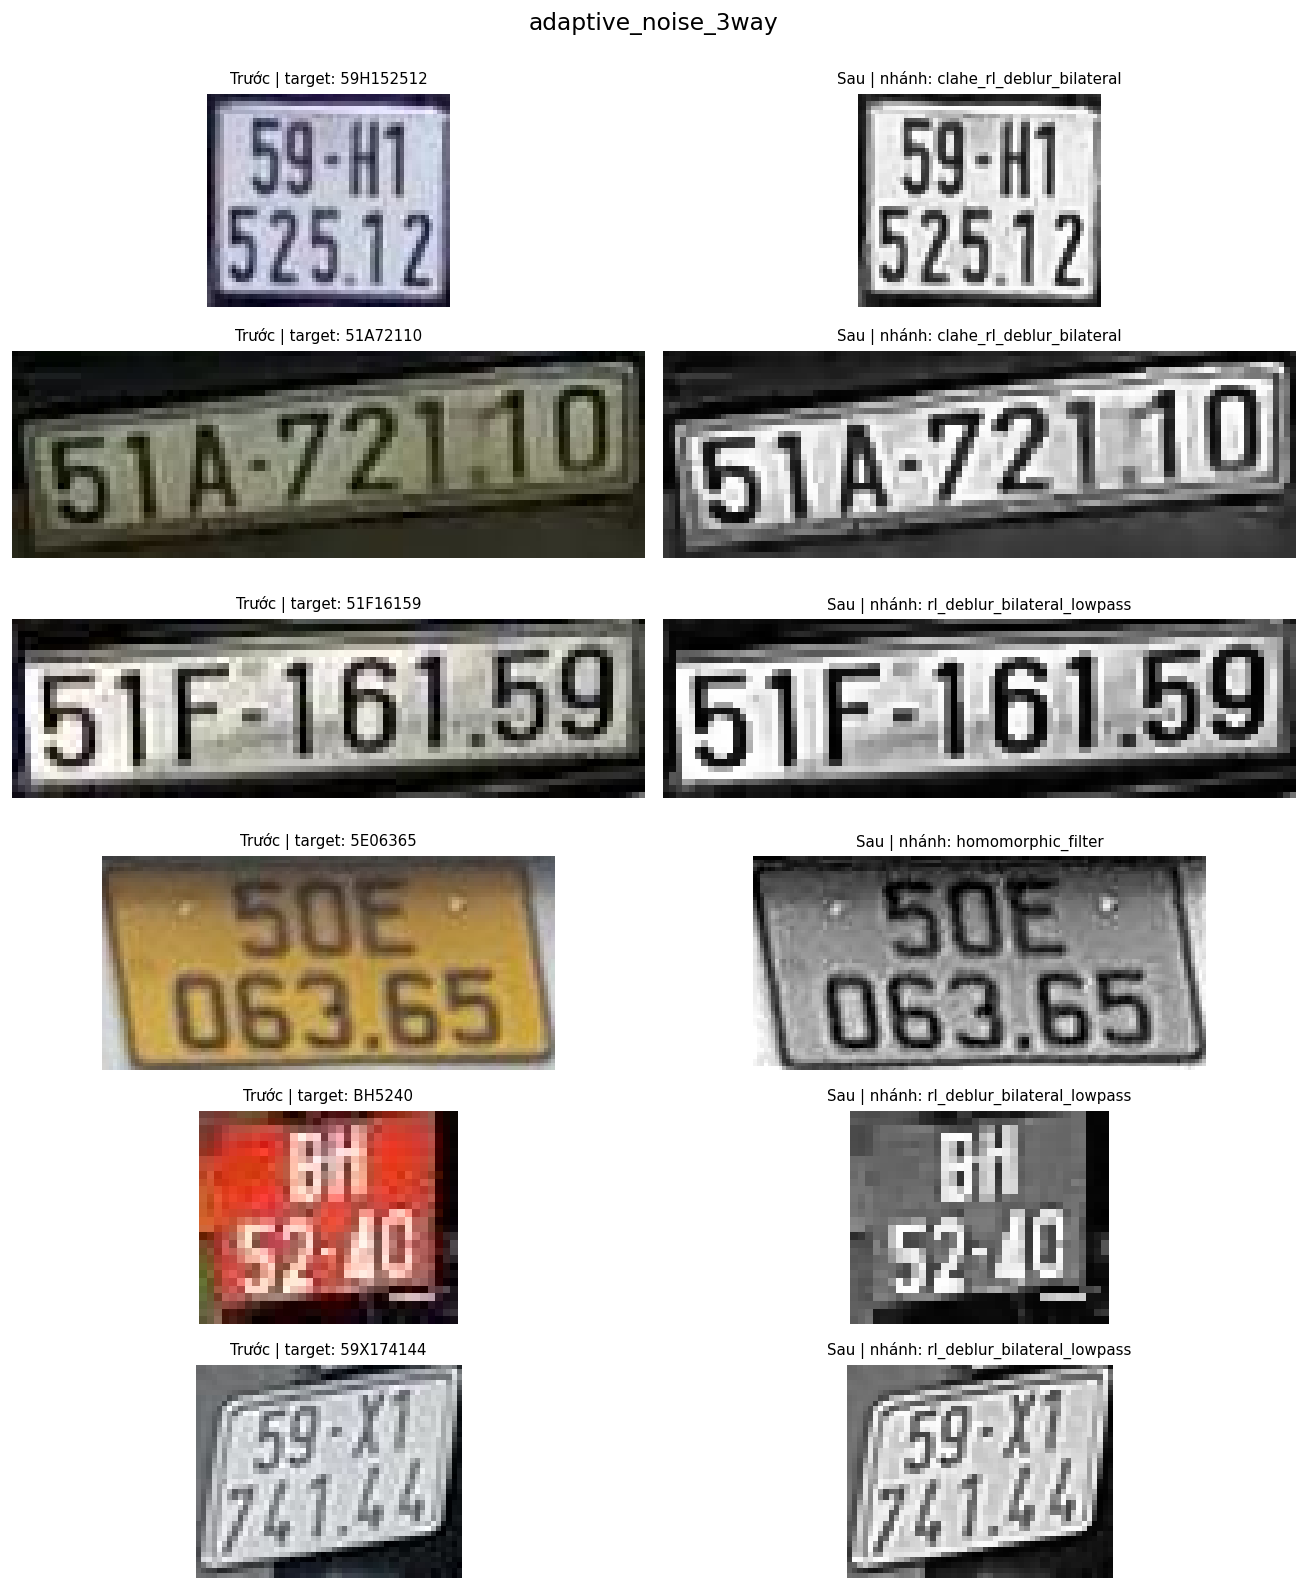


### `clahe_rl_deblur_bilateral`

- Nhóm: Tổ hợp nhiều bước
- Exact match: 93.4307% (+1.4599 điểm % so với baseline)
- Character accuracy: 98.9279% (+0.0596 điểm % so với baseline)
- Vì sao cải thiện: CLAHE làm rõ tương phản cục bộ, Richardson–Lucy phục hồi nét chữ và bilateral giảm nhiễu/ringing sau khử mờ mà vẫn giữ biên.
- Hạn chế: Chuỗi xử lý dài hơn CLAHE đơn; có thể khuếch đại nhiễu ở ảnh vốn đã sắc và CI 95% còn chứa 0.


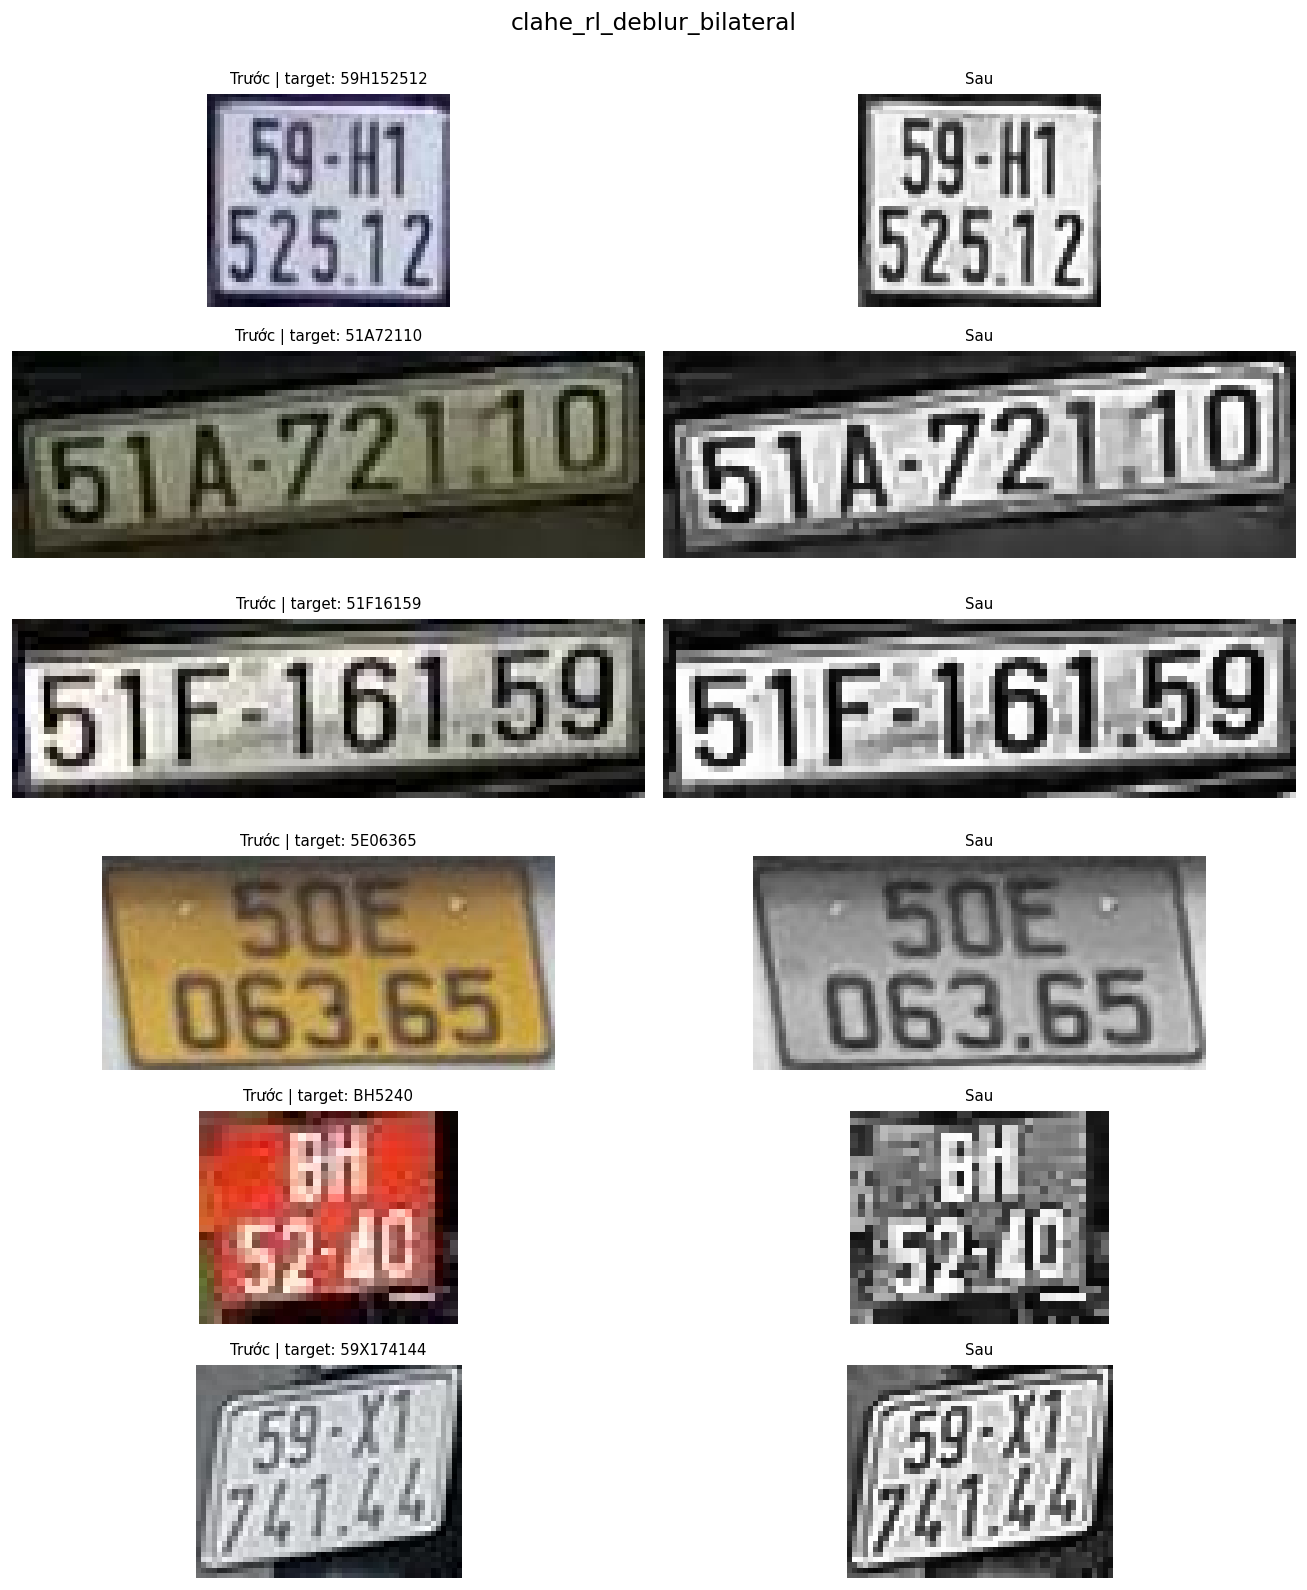


### `clahe_clip1_tile4`

- Nhóm: Tăng cường ảnh truyền thống
- Exact match: 93.1873% (+1.2165 điểm % so với baseline)
- Character accuracy: 99.0768% (+0.2085 điểm % so với baseline)
- Vì sao cải thiện: Tăng tương phản cục bộ giữa nét chữ và nền nhưng mức khuếch đại nhẹ nên ít làm mất rìa khử răng cưa hoặc phóng đại nhiễu.
- Hạn chế: Không phục hồi được nhòe chuyển động mạnh; CI 95% còn chứa 0.


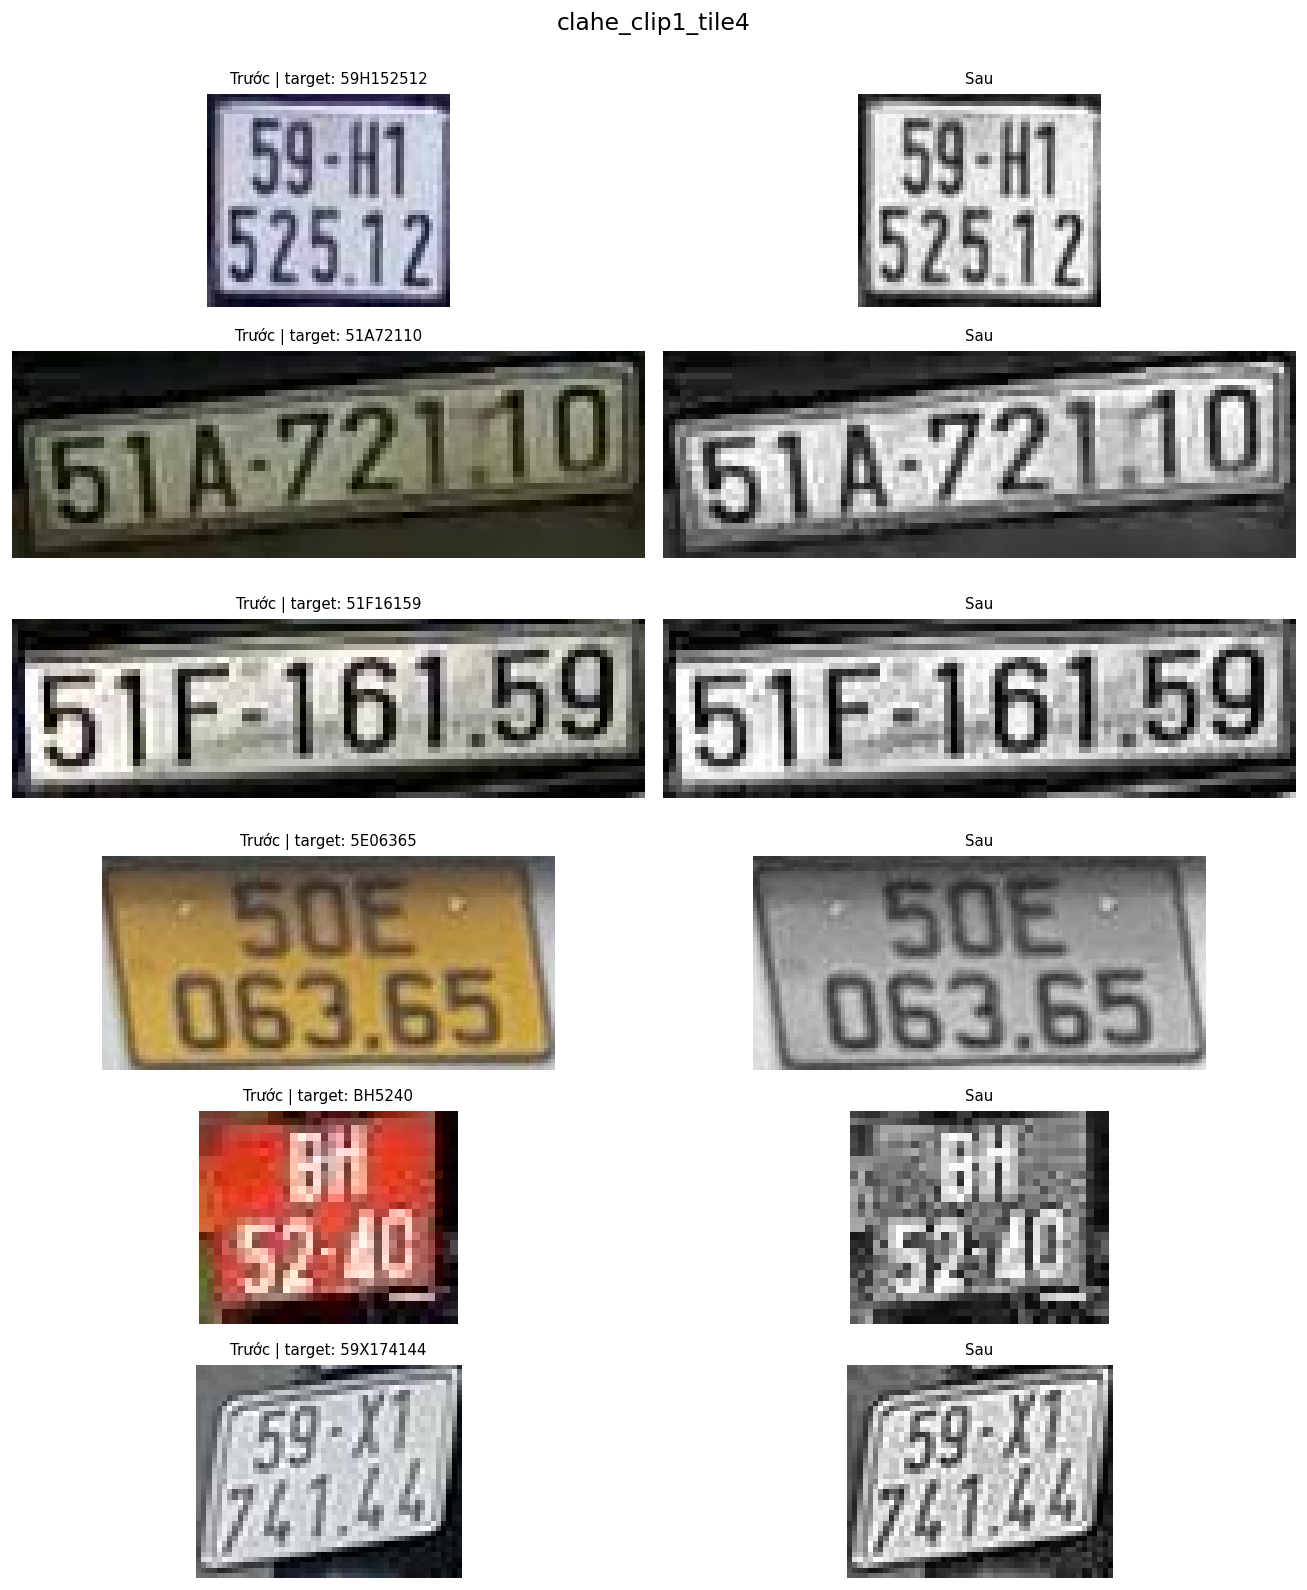


### `raw_rgb`

- Nhóm: Đối chứng đầu vào
- Exact match: 93.1873% (+1.2165 điểm % so với baseline)
- Character accuracy: 98.9875% (+0.1191 điểm % so với baseline)
- Vì sao cải thiện: Giữ lại màu sắc, chi tiết rìa chữ và ngữ cảnh mà chuyển xám hoặc xử lý mạnh có thể làm mất; kết quả cho thấy baseline huấn luyện đã xử lý quá mức một phần ảnh.
- Hạn chế: Đây là đối chứng chứ không phải thuật toán tăng cường ảnh; CI 95% còn chứa 0.


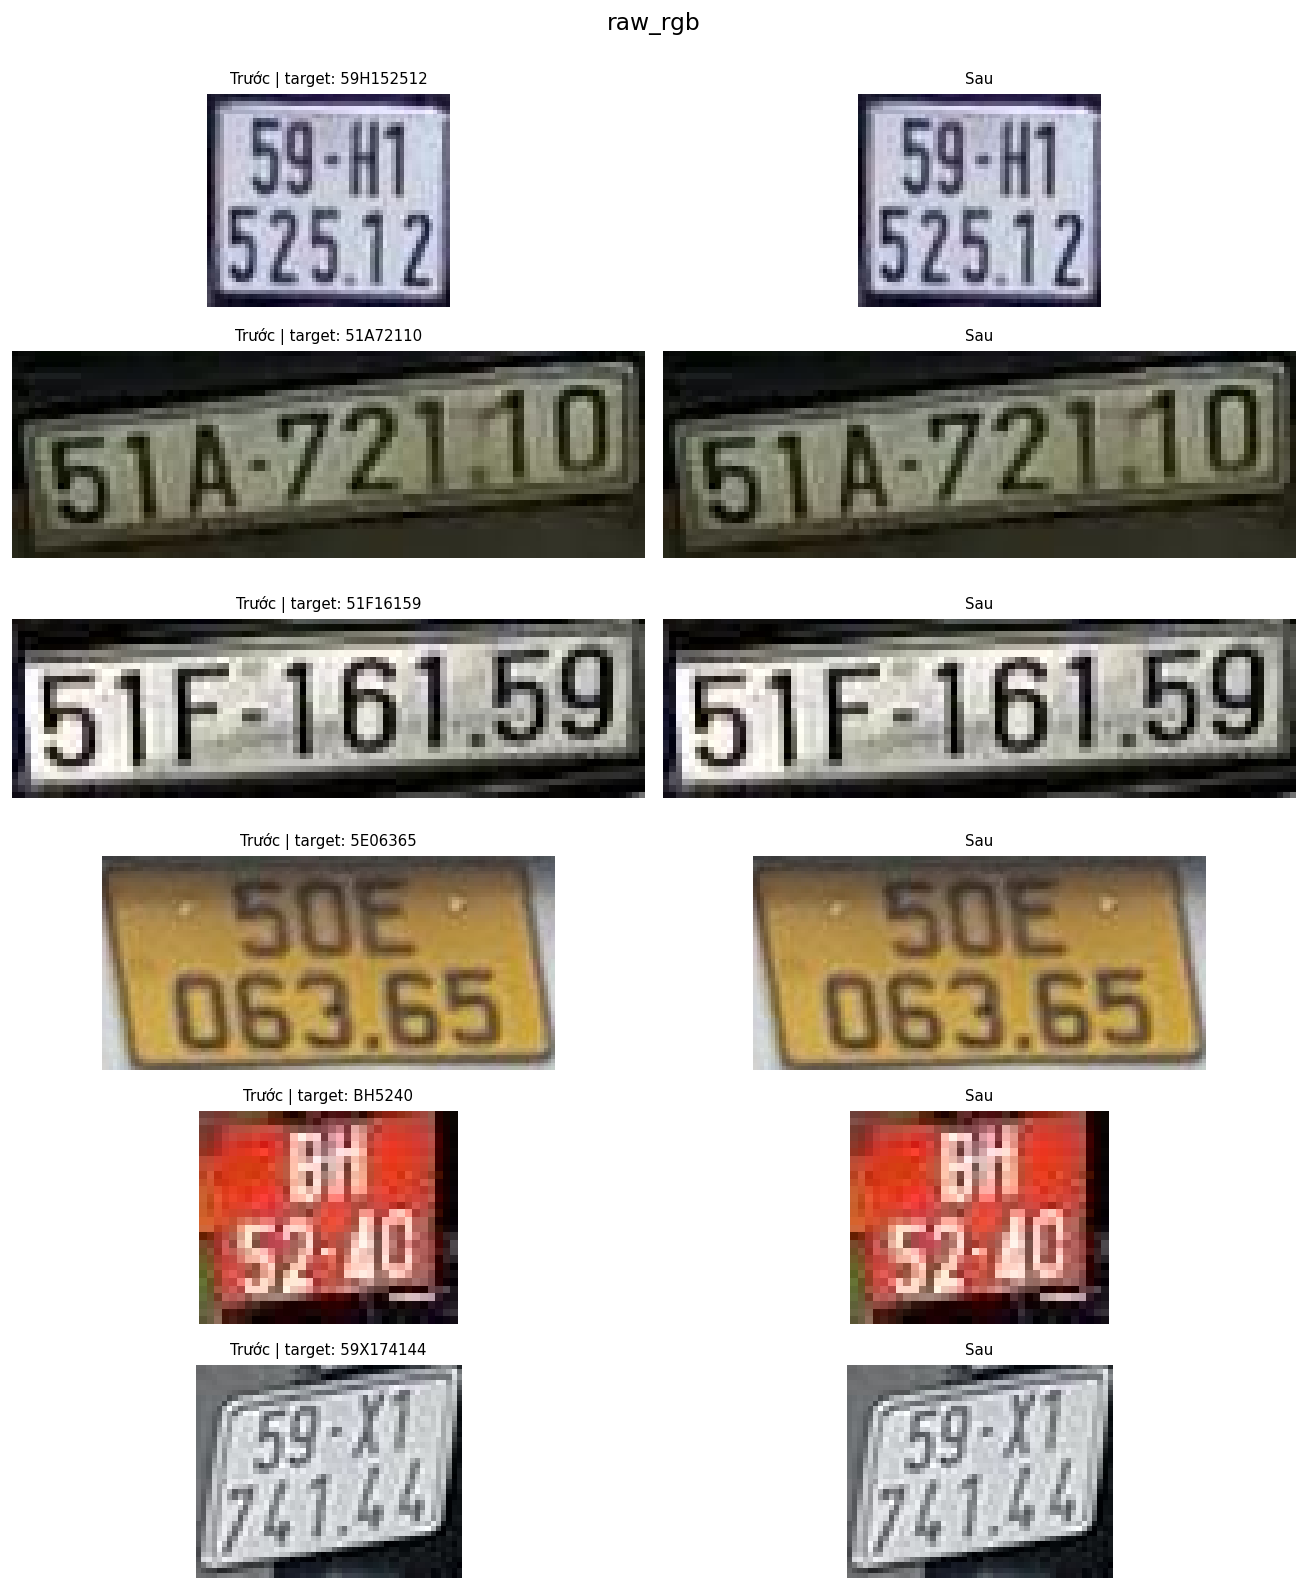


### `adaptive_brightness_3way`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.9440% (+0.9732 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Độ sáng là tín hiệu trực tiếp để chọn phép hiệu chỉnh chiếu sáng/tương phản phù hợp, giảm việc dùng một cấu hình cho mọi ảnh.
- Hạn chế: Số ảnh bị làm sai còn cao (7 ảnh) và CI 95% chứa 0.


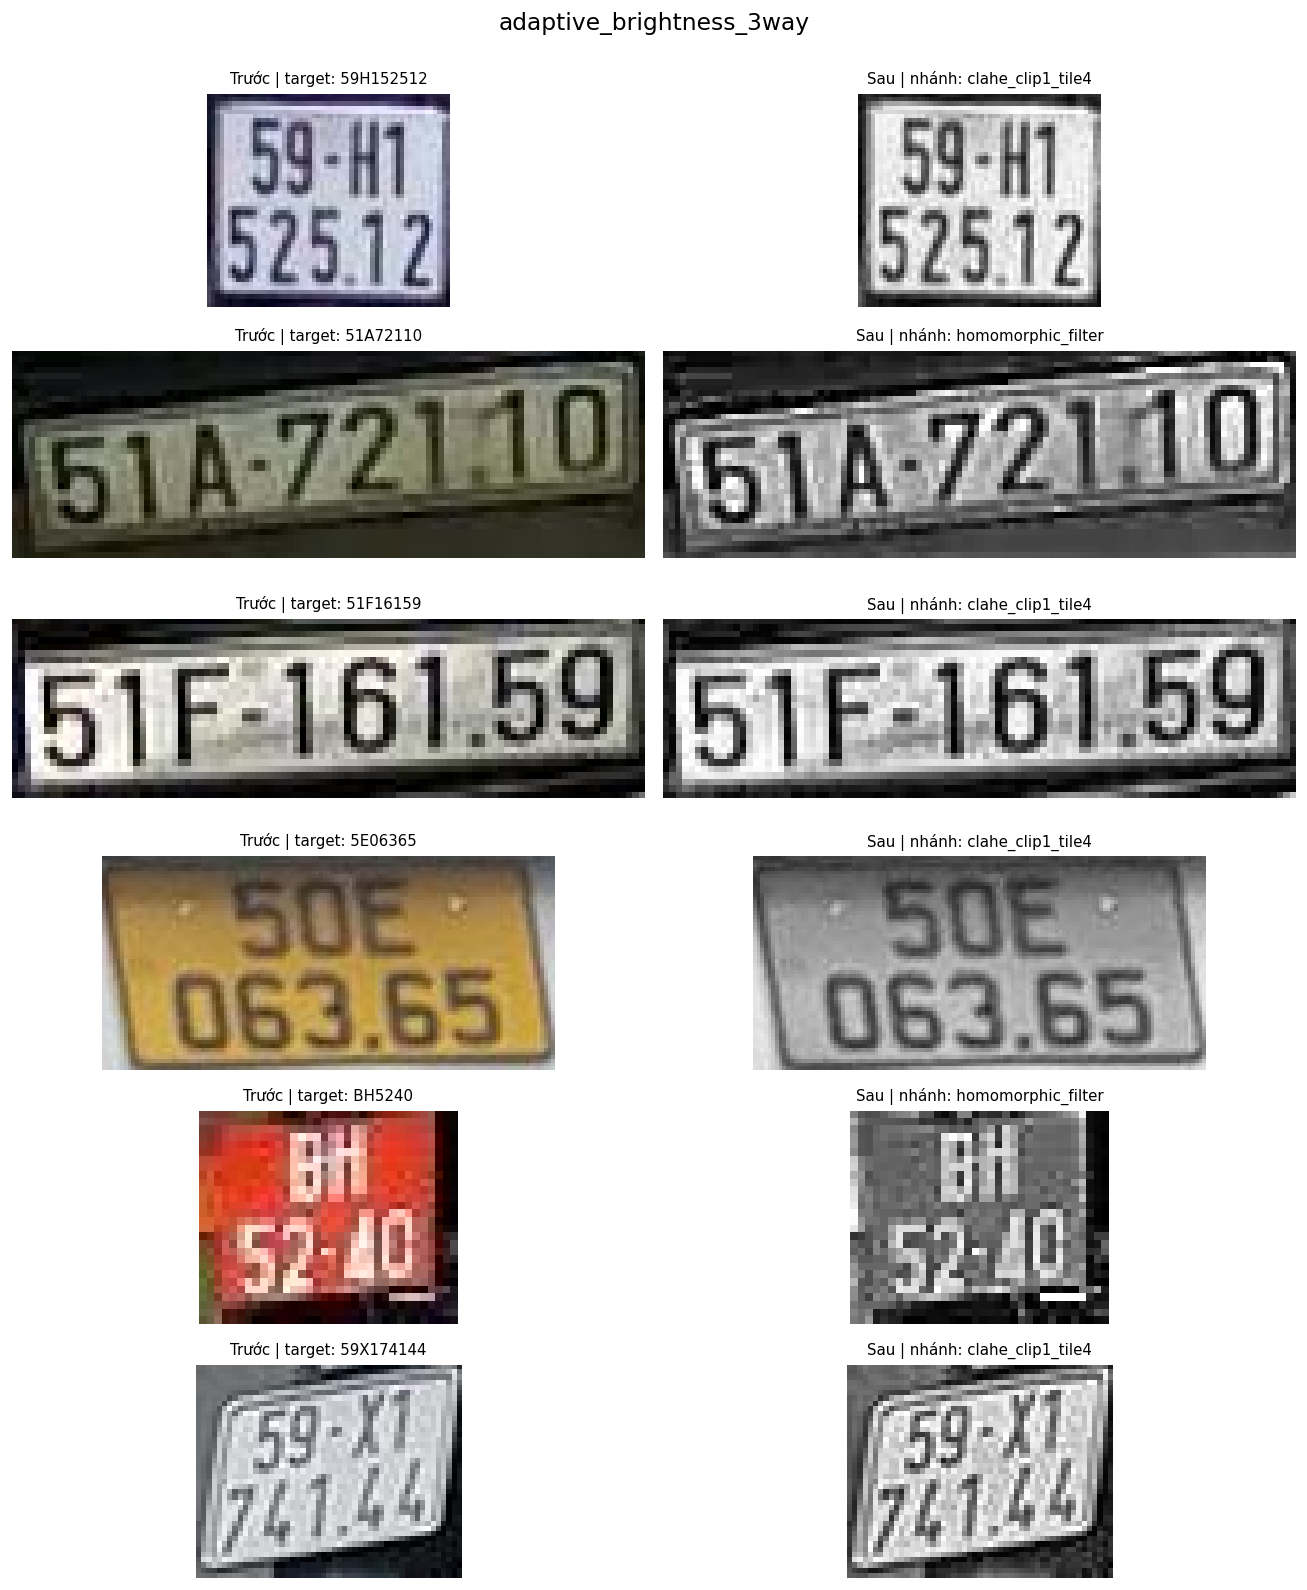


### `adaptive_dark_fraction_3way`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.9440% (+0.9732 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Tỷ lệ vùng tối phản ánh nền biển và điều kiện chiếu sáng tốt hơn độ sáng trung bình ở một số ảnh, từ đó chọn xử lý đúng nhóm.
- Hạn chế: Ngưỡng phụ thuộc loại biển số và điều kiện chụp; CI 95% chứa 0.


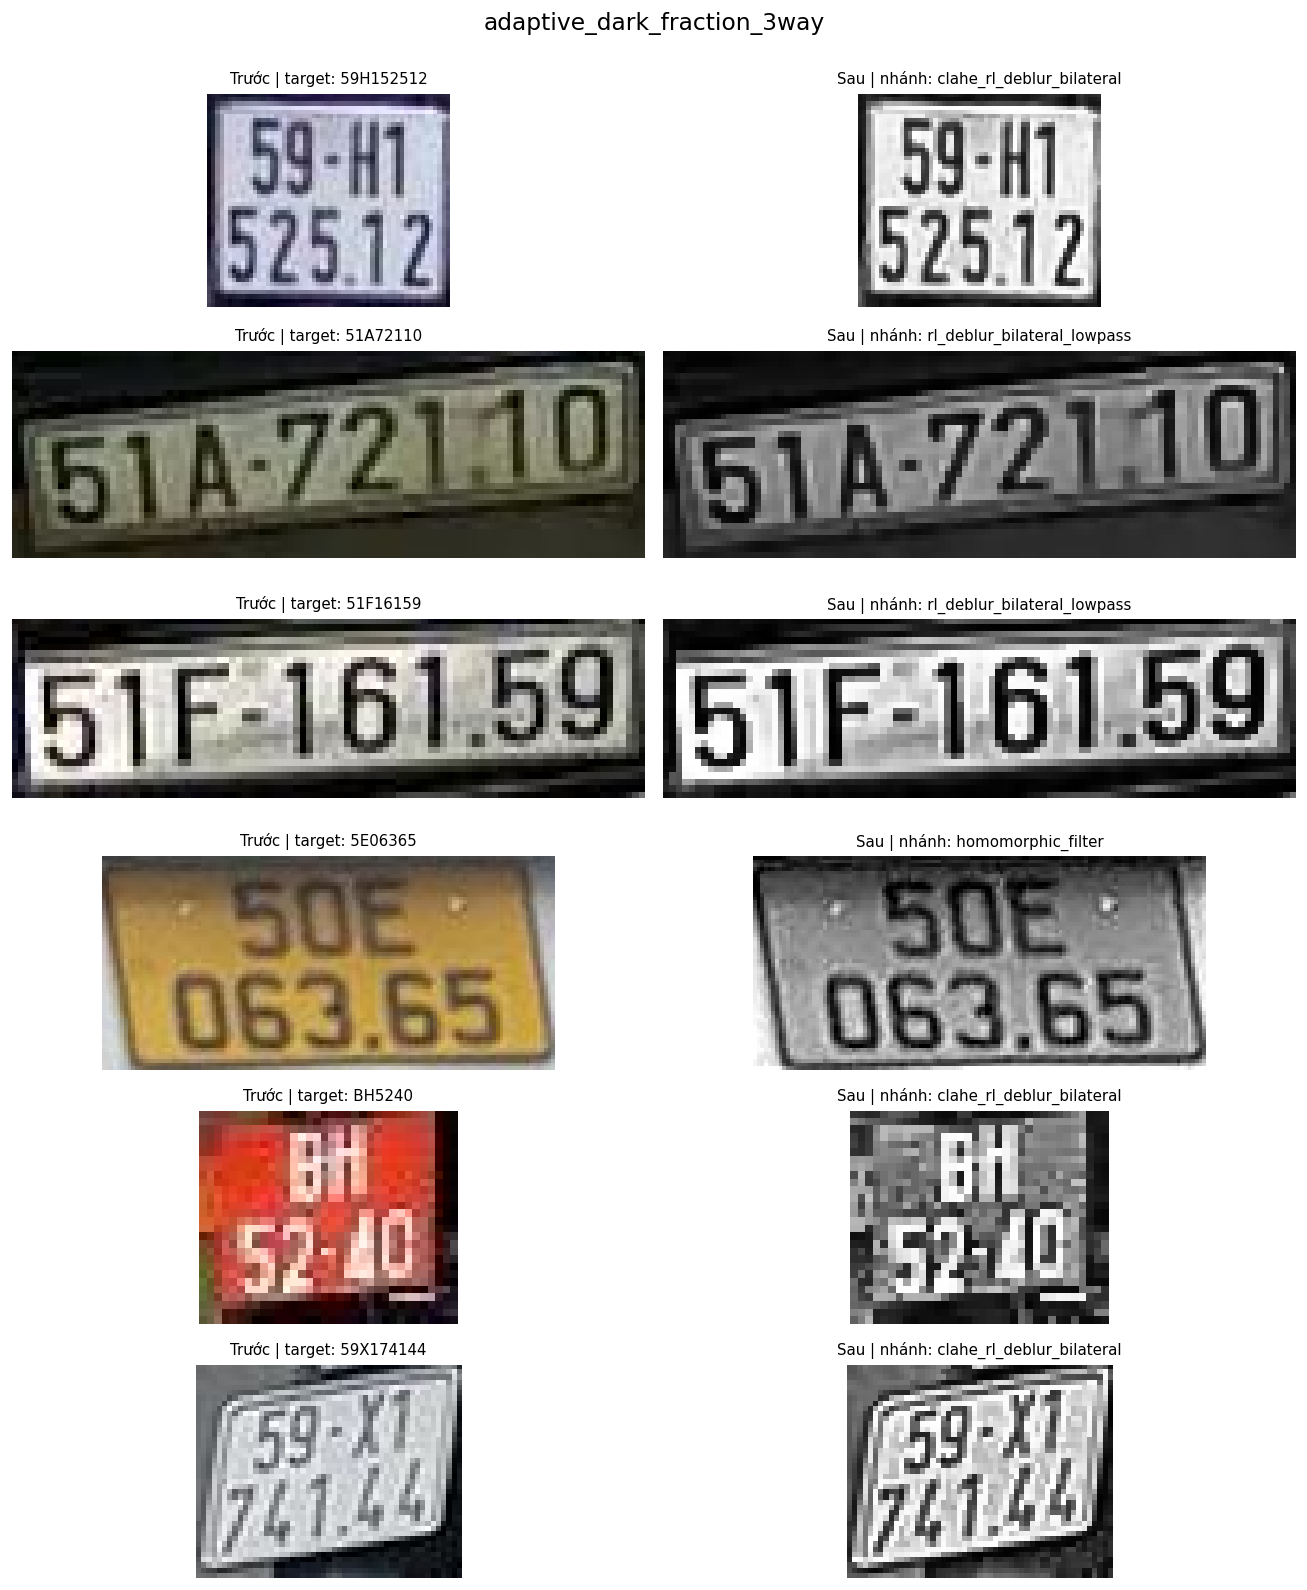


### `percentile_stretch_2_98`

- Nhóm: Tăng cường ảnh truyền thống
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Bỏ qua các điểm sáng/tối ngoại lai rồi mở rộng dải động hữu ích, làm khoảng cách cường độ giữa chữ và nền rõ hơn.
- Hạn chế: Tăng tương phản toàn cục nên có thể mất chi tiết ở vùng cực sáng/tối; CI 95% chứa 0.


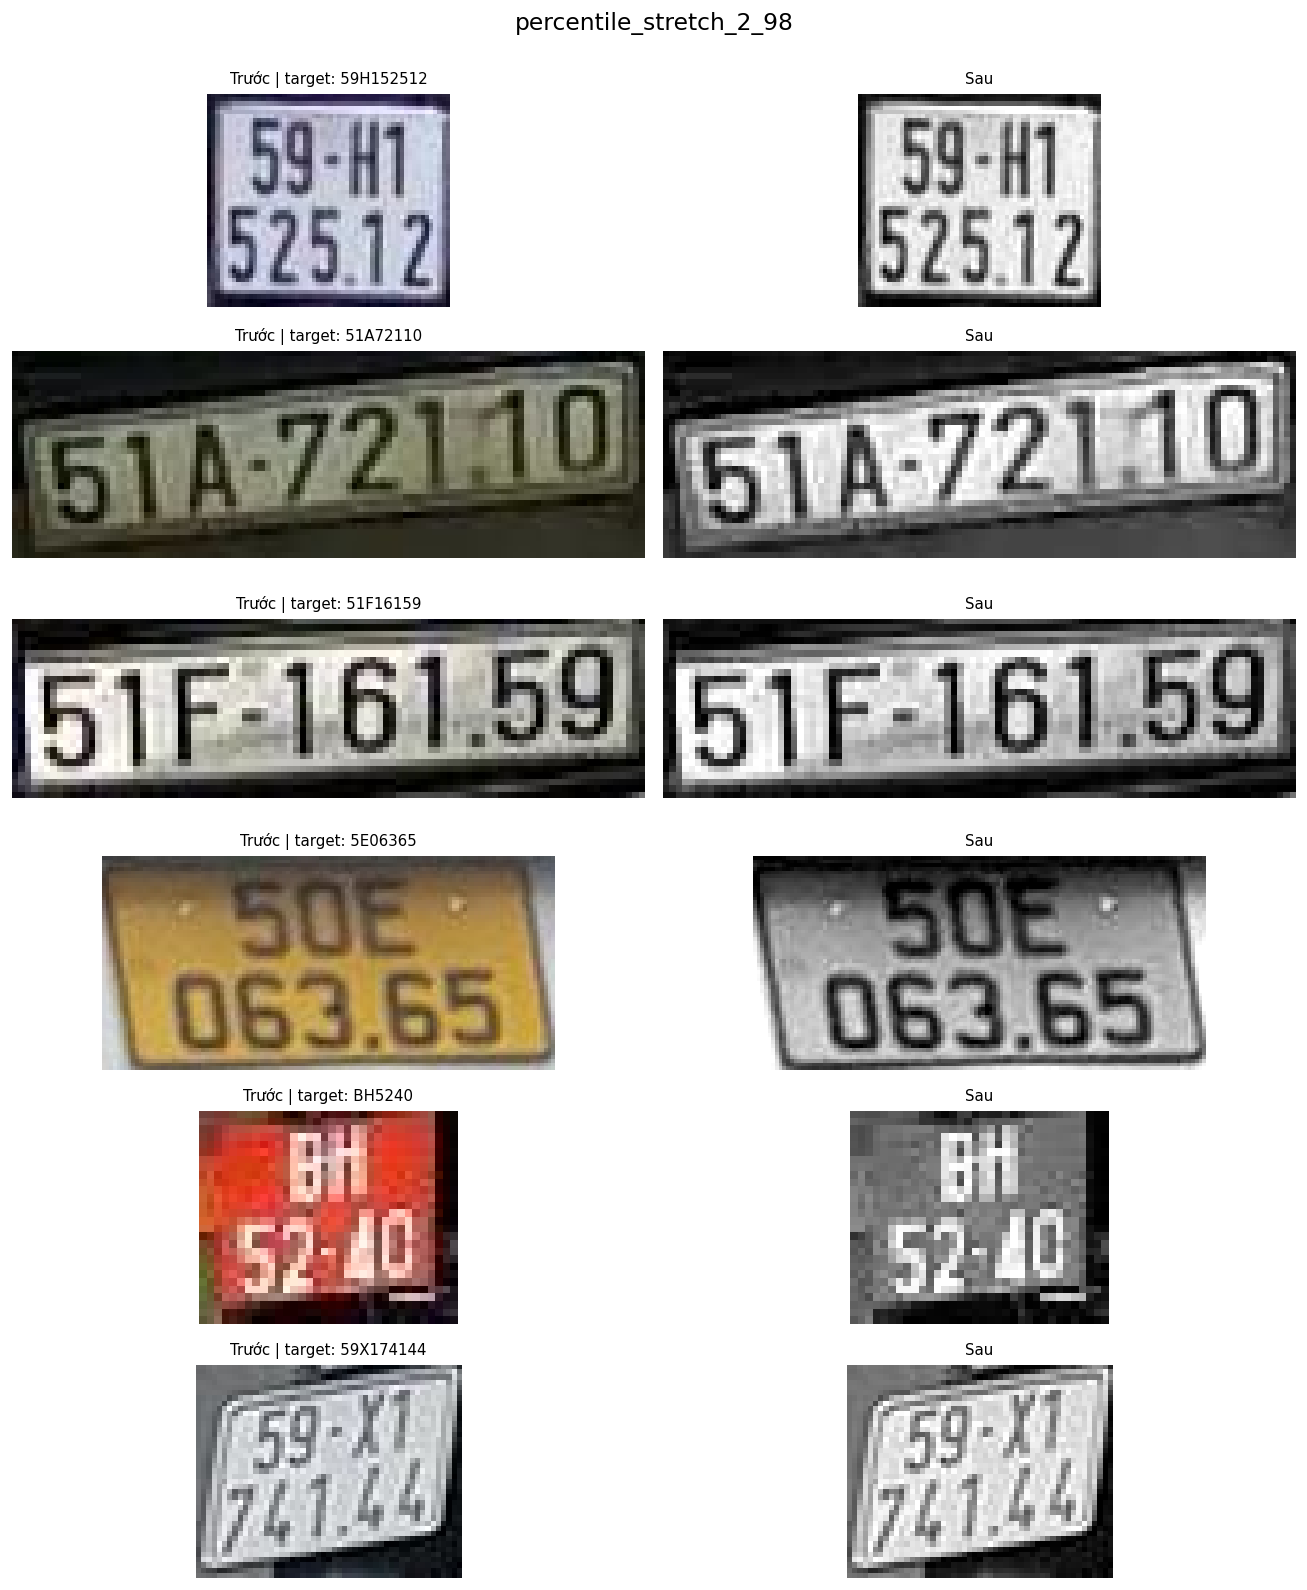


### `autocontrast`

- Nhóm: Tăng cường ảnh truyền thống
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Tận dụng toàn bộ dải cường độ để tách nét chữ khỏi nền trên các ảnh có tương phản thấp.
- Hạn chế: Nhạy với điểm ảnh ngoại lai hơn percentile stretch và CI 95% chứa 0.


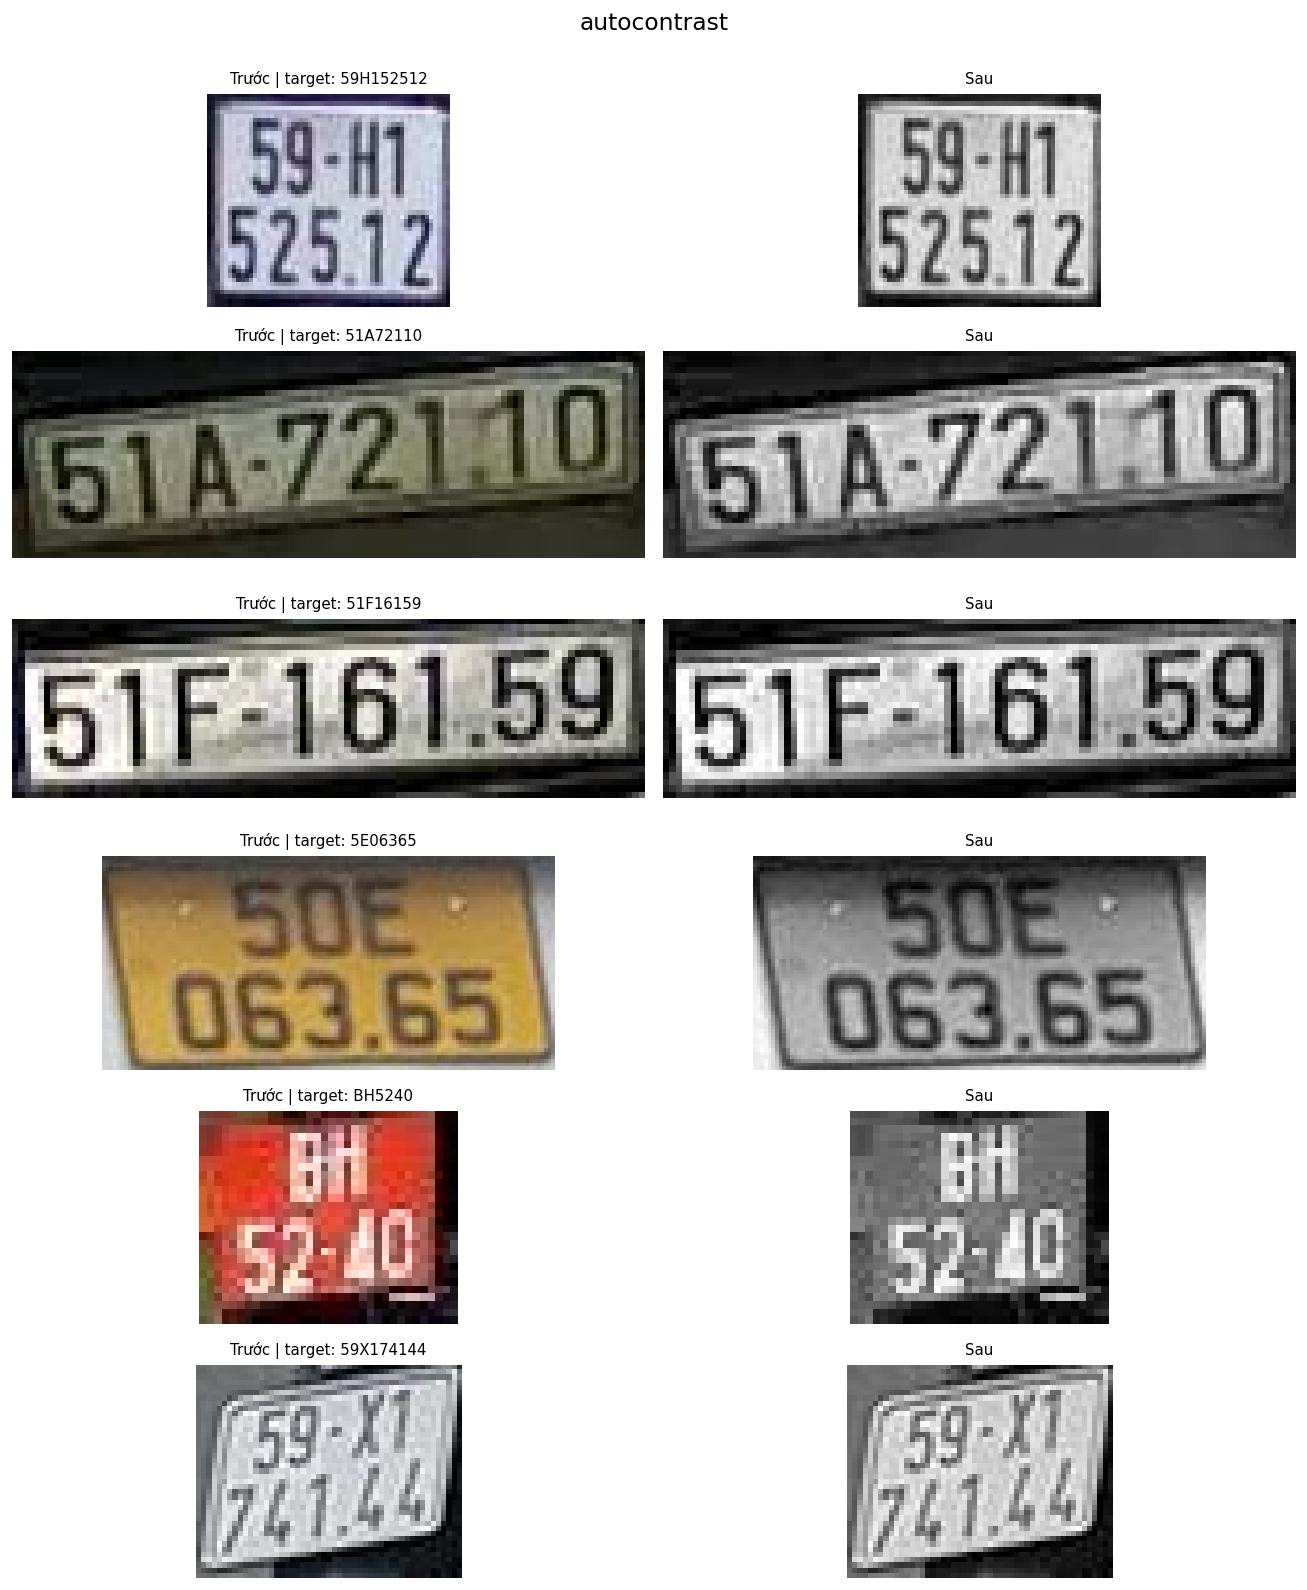


### `channel_green`

- Nhóm: Xử lý đa kênh
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Kênh xanh lục có tỷ lệ tín hiệu/nhiễu và độ tương phản chữ–nền tốt trên một phần dữ liệu, giảm nhiễu màu từ các kênh còn lại.
- Hạn chế: Hiệu quả phụ thuộc màu biển số/camera và CI 95% chứa 0.


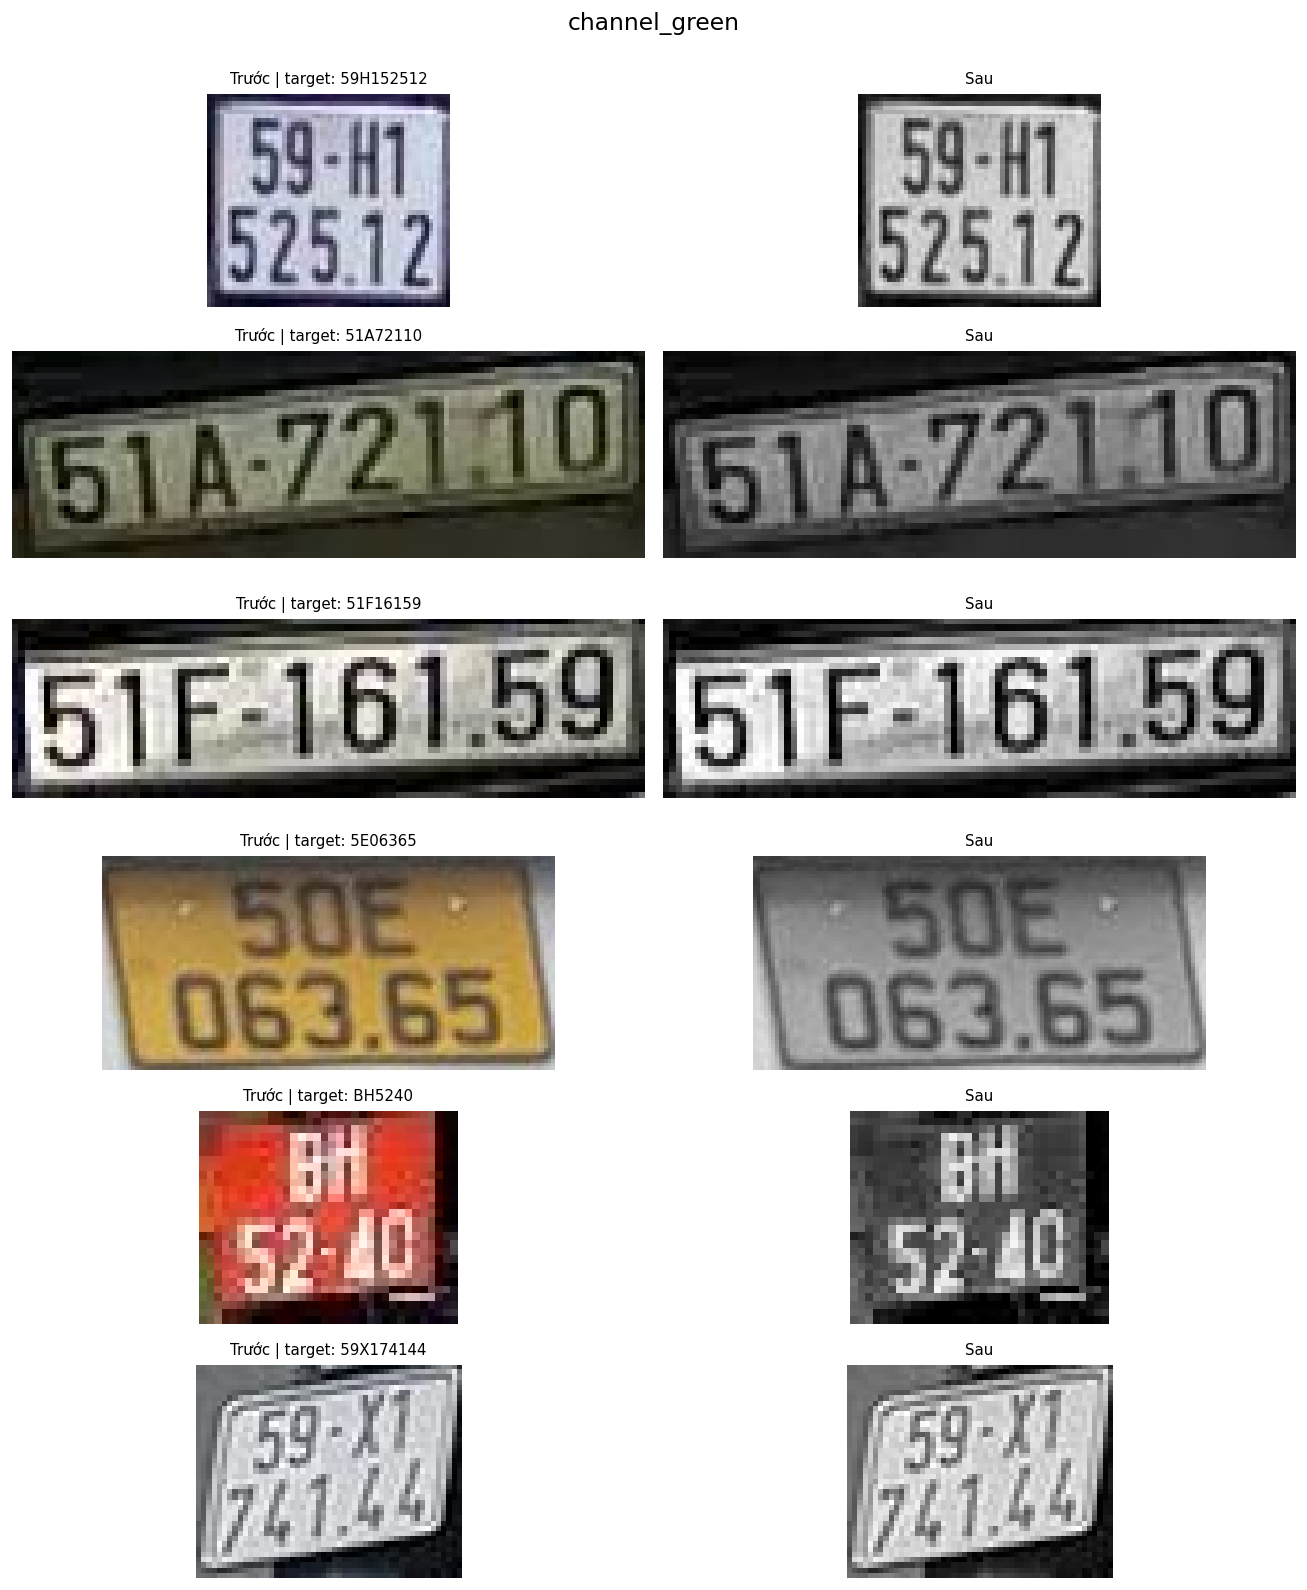


### `gamma_1_1`

- Nhóm: Biến đổi mức xám
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.9577% (+0.0893 điểm % so với baseline)
- Vì sao cải thiện: Làm tối nhẹ vùng sáng và tăng độ tách biệt của nét chữ tối trên các biển bị bạc màu hoặc dư sáng.
- Hạn chế: Có thể làm mất chi tiết ở ảnh vốn tối; CI 95% chứa 0.


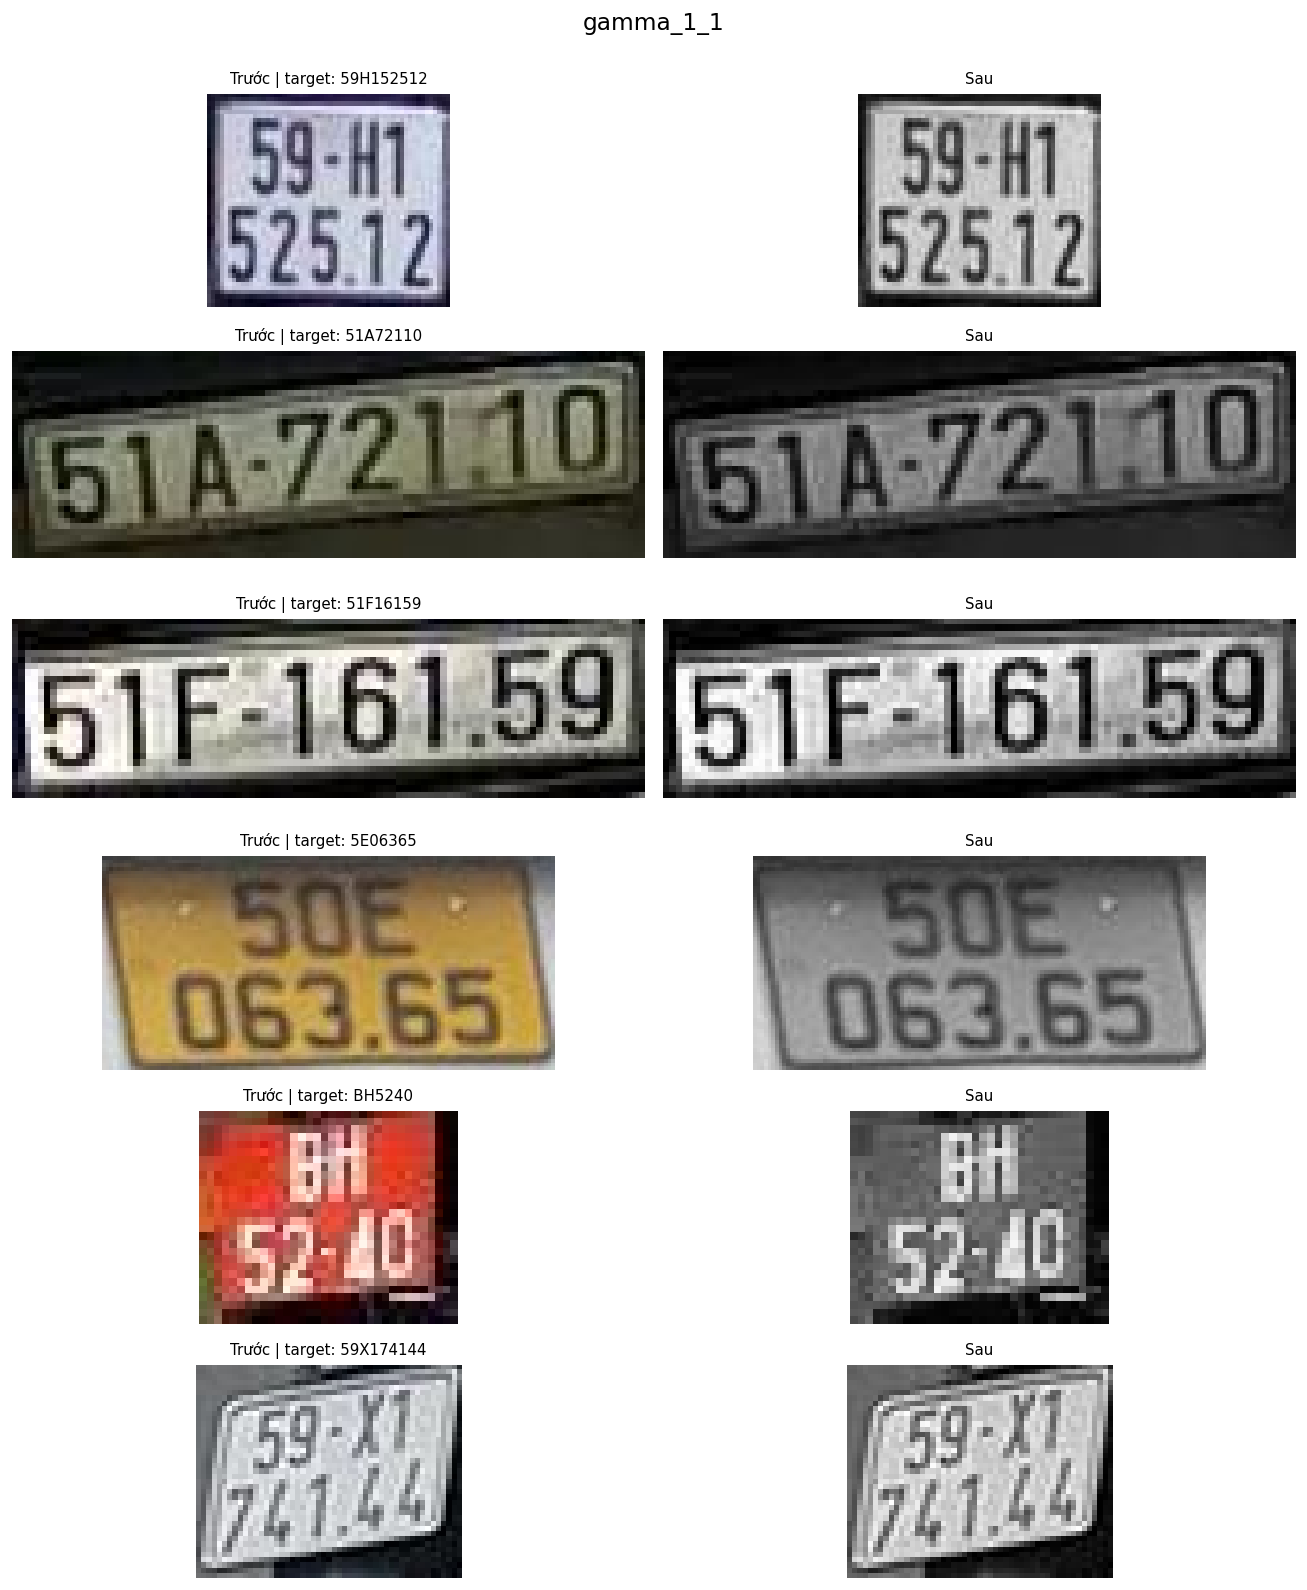


### `homomorphic_unsharp_025`

- Nhóm: Tổ hợp nhiều bước
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.9279% (+0.0596 điểm % so với baseline)
- Vì sao cải thiện: Homomorphic giảm biến thiên chiếu sáng chậm, sau đó unsharp nhấn nhẹ biên nét chữ để mô hình đọc hình dạng rõ hơn.
- Hạn chế: Có thể khuếch đại nhiễu/halo; số ảnh làm sai là 7 và CI 95% chứa 0.


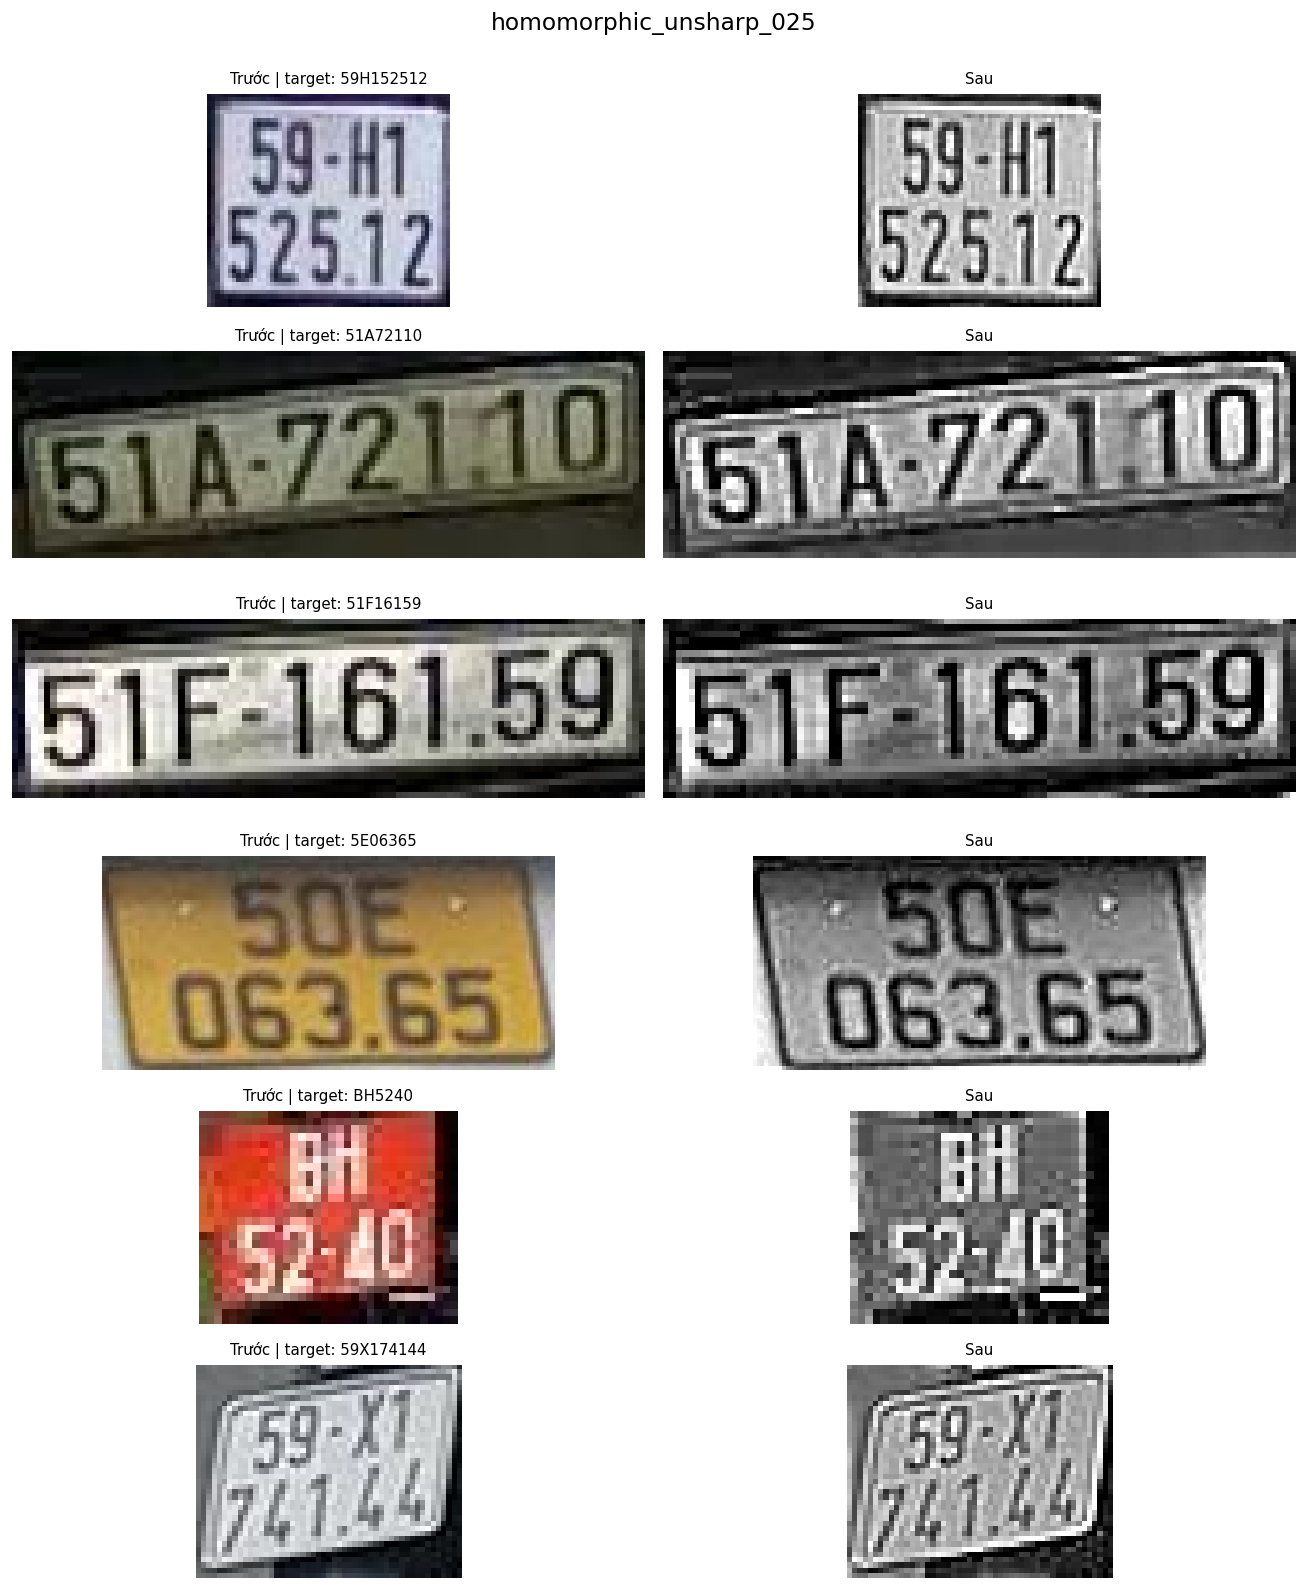


### `adaptive_quality_conservative`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.8982% (+0.0298 điểm % so với baseline)
- Vì sao cải thiện: Nhiều đặc trưng chất lượng giúp chỉ kích hoạt homomorphic hoặc khử mờ khi ảnh thực sự cần, hạn chế phá hỏng ảnh tốt.
- Hạn chế: Lợi ích character accuracy rất nhỏ, 7 ảnh bị làm sai và CI 95% chứa 0.


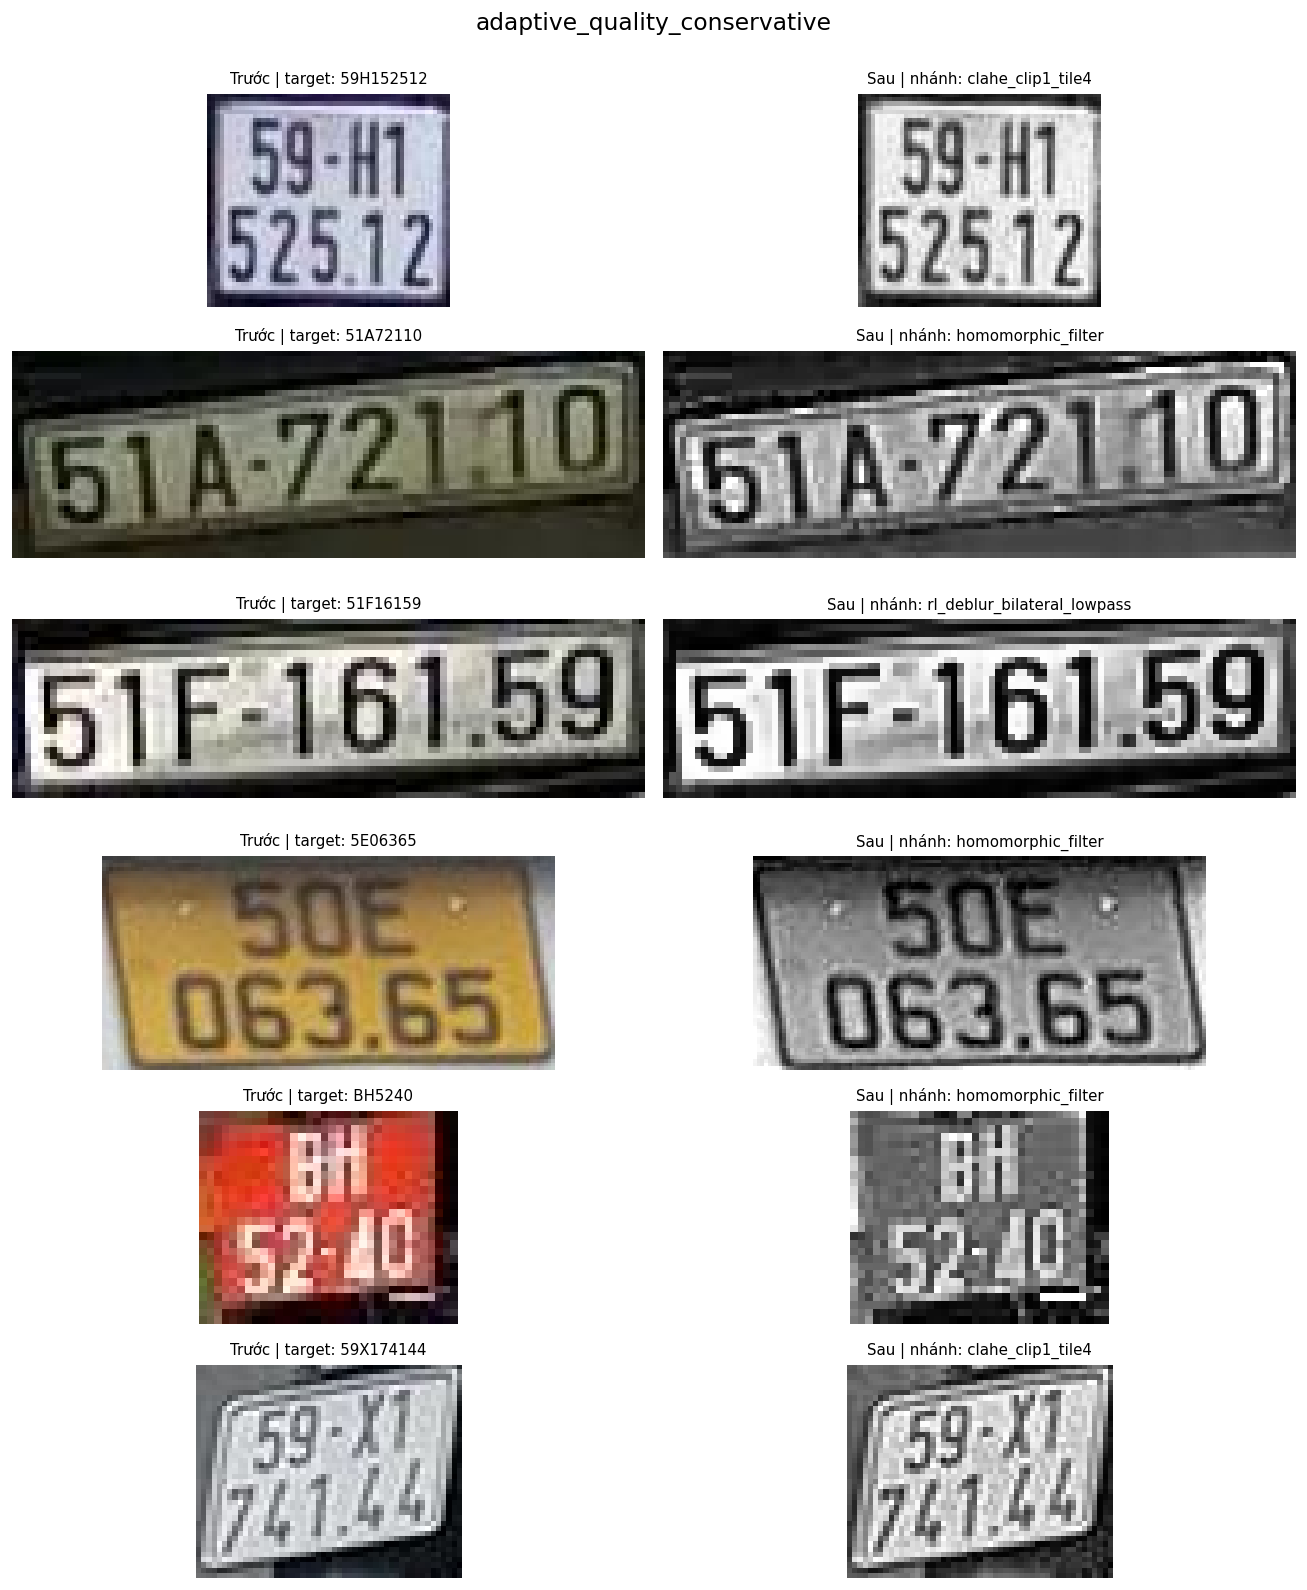


### `adaptive_small_then_quality`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.8982% (+0.0298 điểm % so với baseline)
- Vì sao cải thiện: Ảnh crop nhỏ được tăng/khôi phục chi tiết trước khi đánh giá chất lượng, giúp giảm mất nét do resize ở một số biển số xa.
- Hạn chế: Pipeline phức tạp, tăng độ trễ và lợi ích character accuracy nhỏ; CI 95% chứa 0.


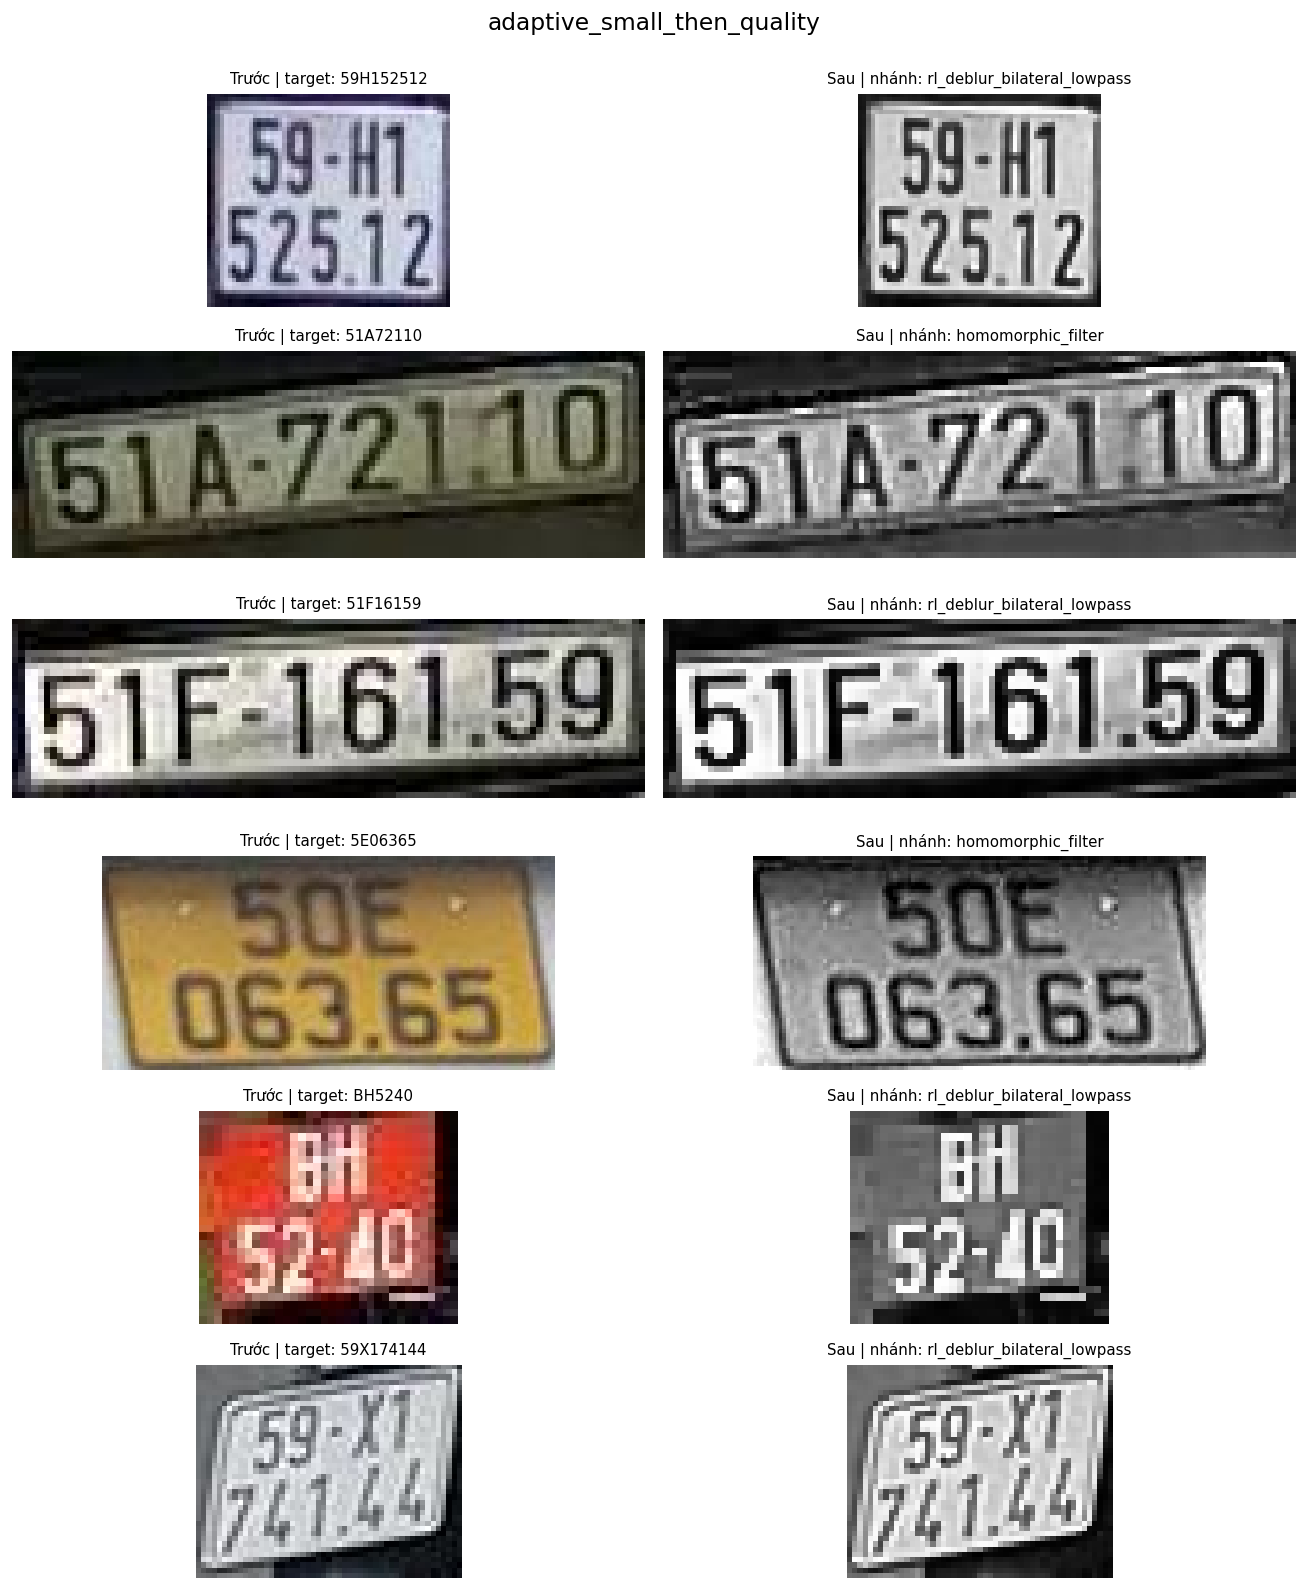


### `adaptive_quality_cv`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.7007% (+0.7299 điểm % so với baseline)
- Character accuracy: 98.8684% (+0.0000 điểm % so với baseline)
- Vì sao cải thiện: Kết hợp tín hiệu độ sáng, tương phản, màu và độ sắc nét để chọn xử lý theo từng ảnh.
- Hạn chế: Chỉ tăng exact match, character accuracy không đổi; có dấu hiệu quá khớp validation và CI 95% chứa 0.


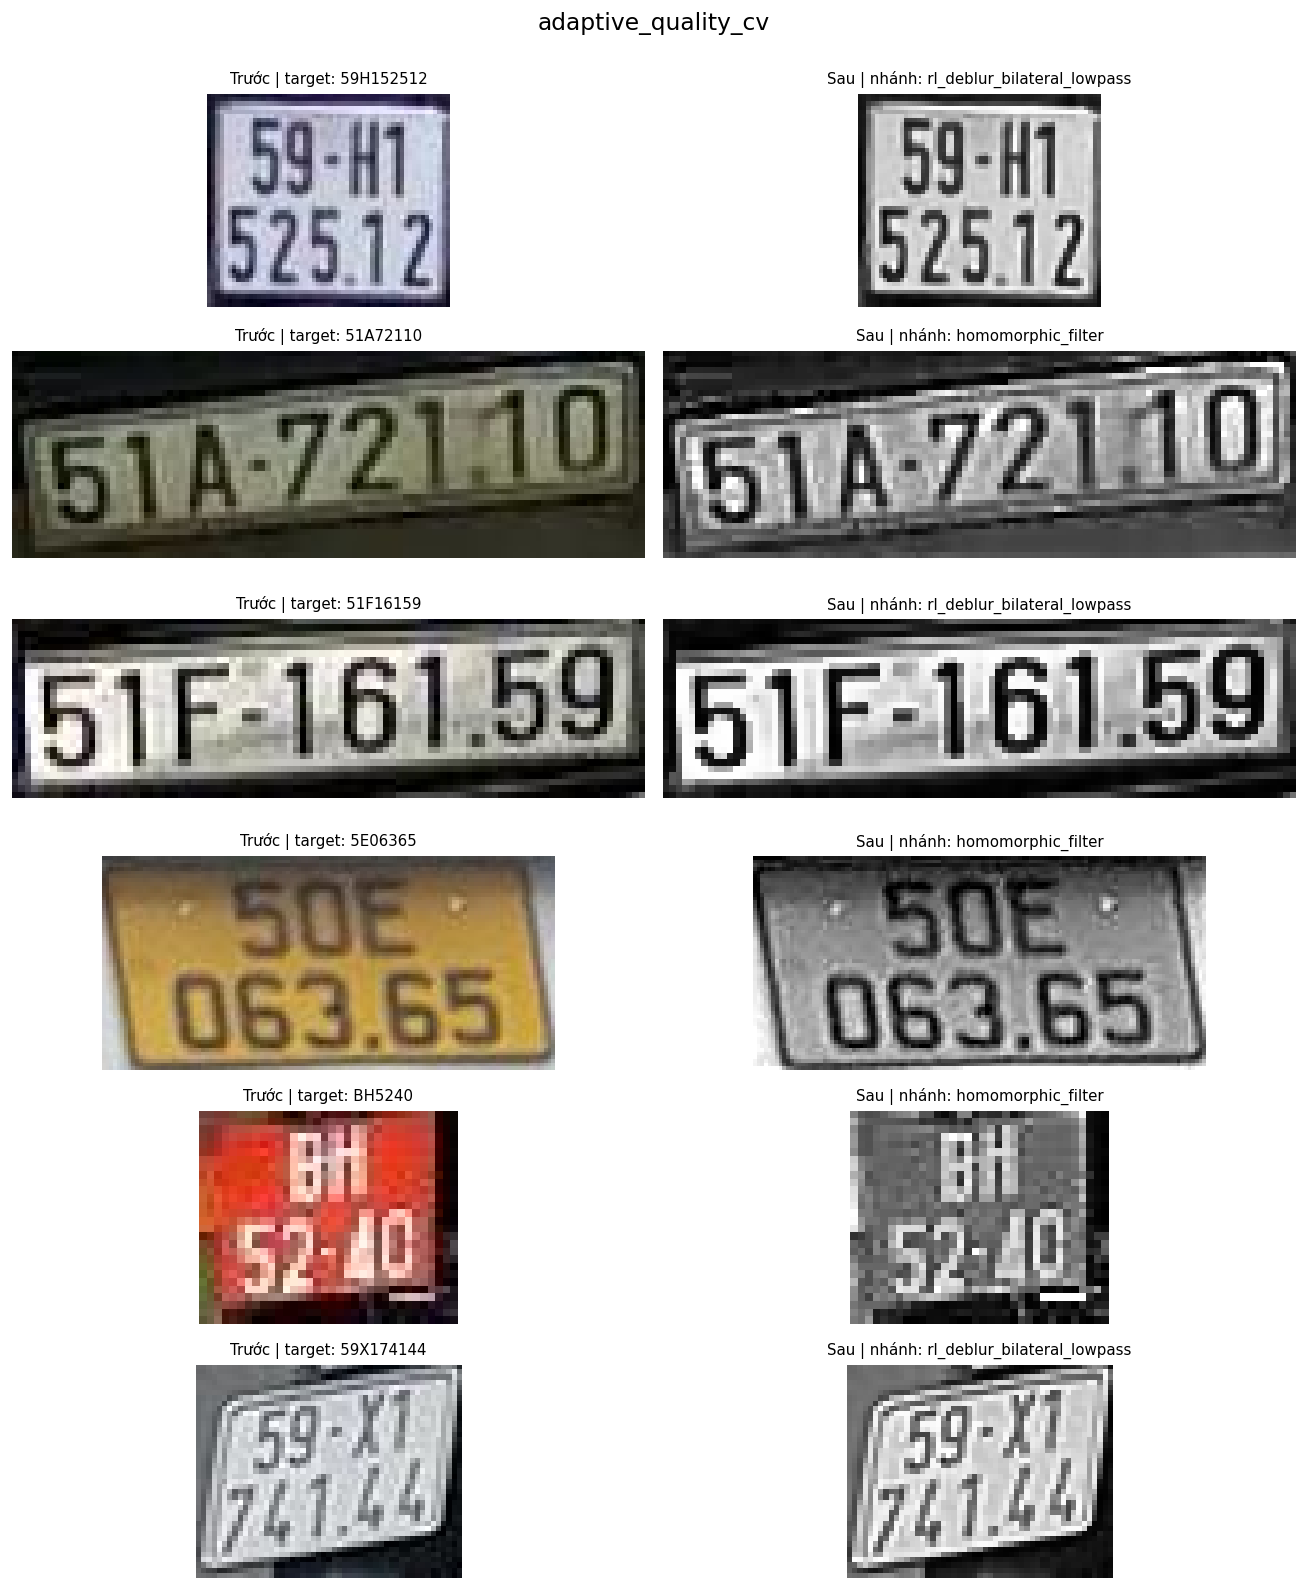


### `homomorphic_dual_stroke_mild`

- Nhóm: Tổ hợp nhiều bước
- Exact match: 92.4574% (+0.4866 điểm % so với baseline)
- Character accuracy: 98.9279% (+0.0596 điểm % so với baseline)
- Vì sao cải thiện: Hiệu chỉnh chiếu sáng rồi làm rõ cả chữ tối trên nền sáng và chữ sáng trên nền tối, phù hợp dữ liệu có nhiều kiểu biển.
- Hạn chế: Có 8 ảnh bị làm sai và CI 95% chứa 0; phép hình thái học có thể làm biến dạng nét mảnh.


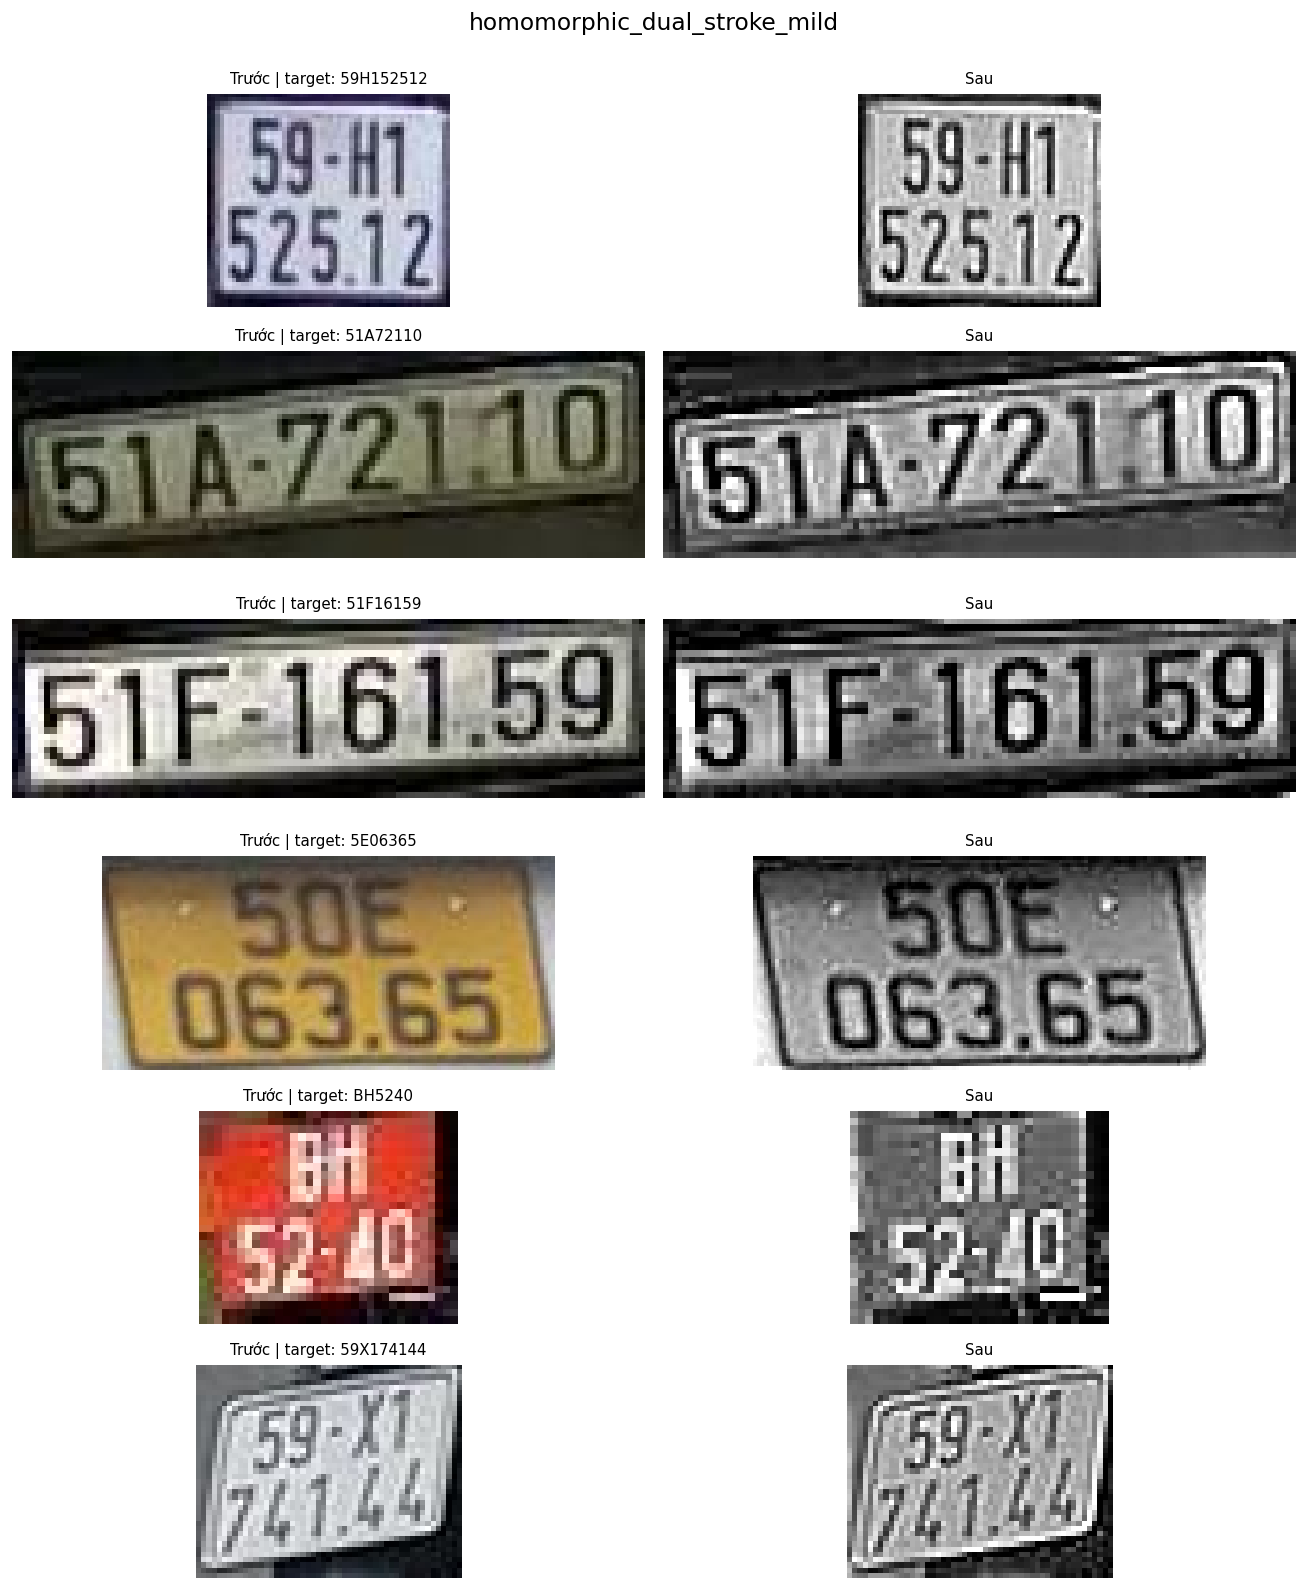


### `homomorphic_filter`

- Nhóm: Khôi phục chiếu sáng
- Exact match: 92.4574% (+0.4866 điểm % so với baseline)
- Character accuracy: 98.8684% (+0.0000 điểm % so với baseline)
- Vì sao cải thiện: Tách thành phần chiếu sáng chậm khỏi phản xạ/nét chữ, giúp giảm bóng và độ sáng không đều.
- Hạn chế: Character accuracy không tăng, 7 ảnh bị làm sai và CI 95% chứa 0.


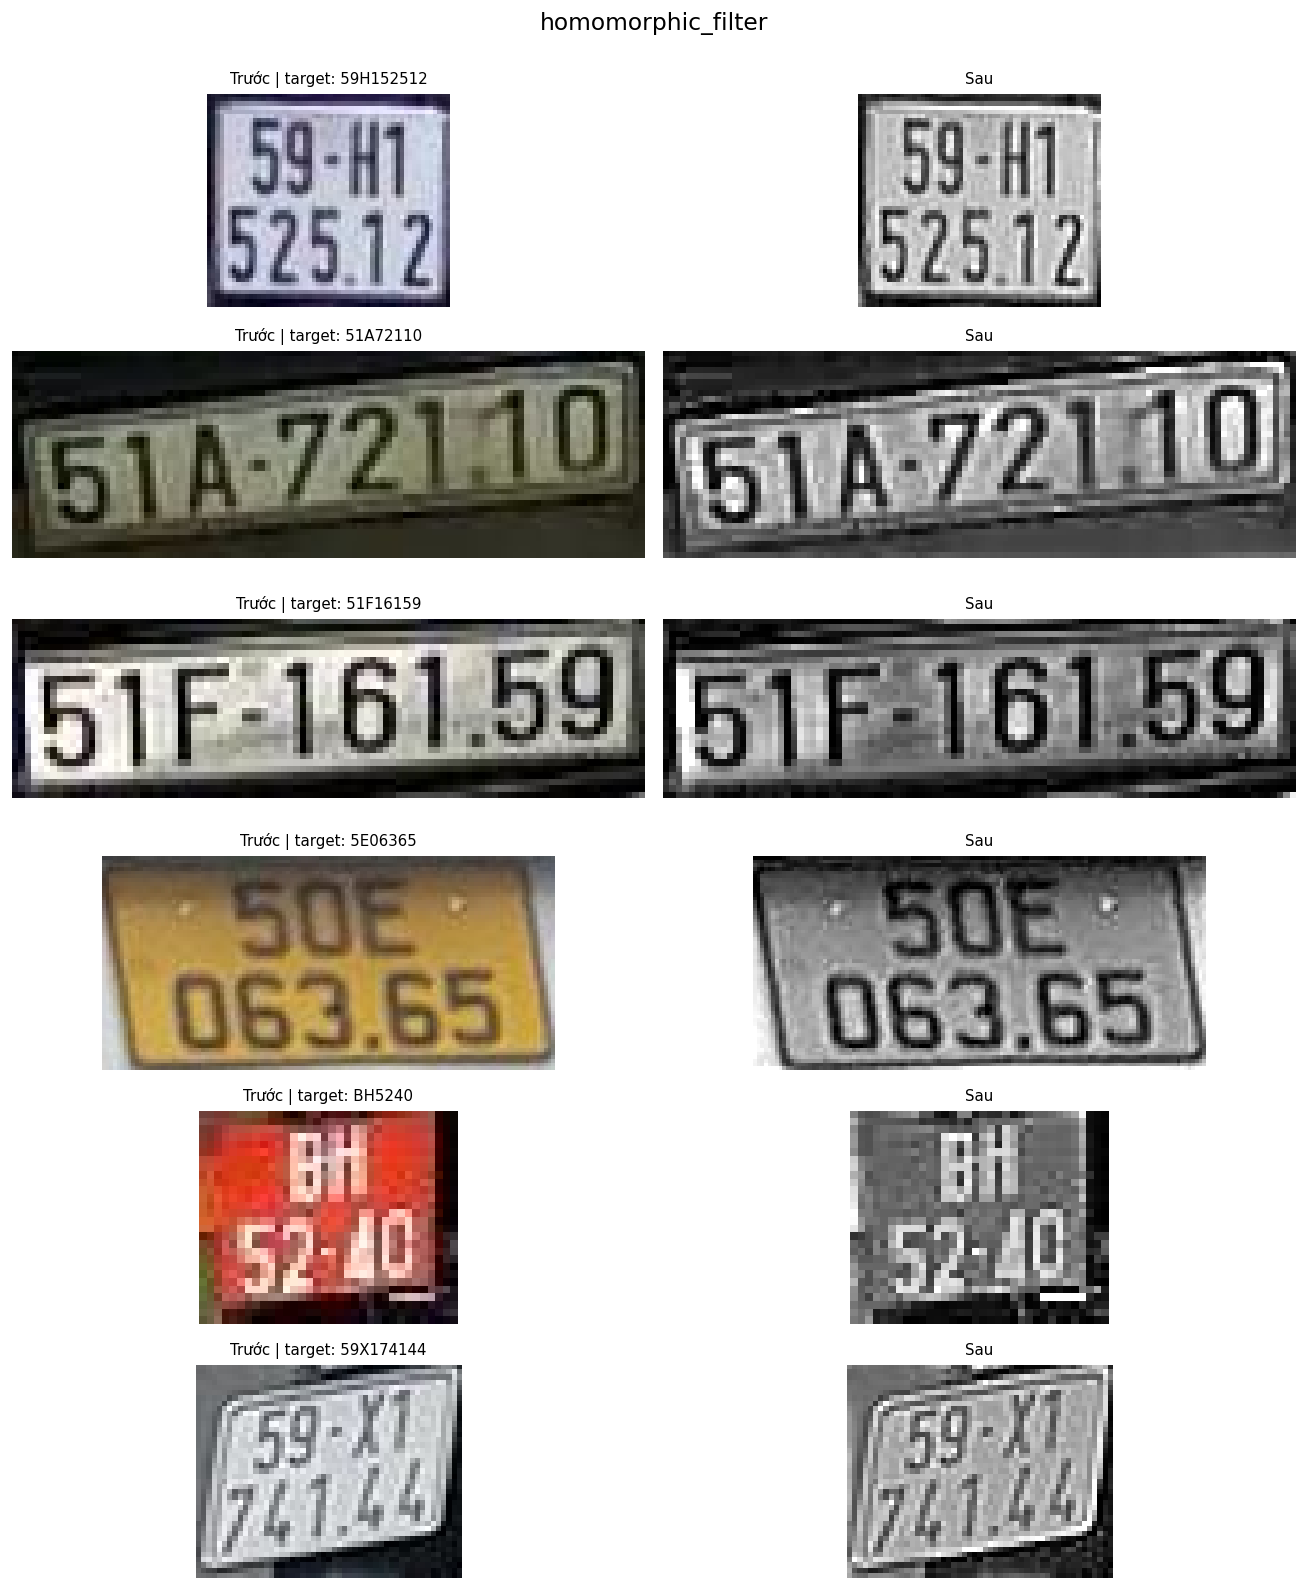


### `adaptive_size_3way`

- Nhóm: Tiền xử lý thích ứng
- Exact match: 92.4574% (+0.4866 điểm % so với baseline)
- Character accuracy: 98.8088% (-0.0596 điểm % so với baseline)
- Vì sao cải thiện: Kích thước crop đại diện cho lượng chi tiết khả dụng, cho phép phục hồi mạnh hơn ở ảnh nhỏ và giữ nguyên ảnh lớn.
- Hạn chế: Exact match tăng nhưng character accuracy giảm; CI 95% chứa 0.


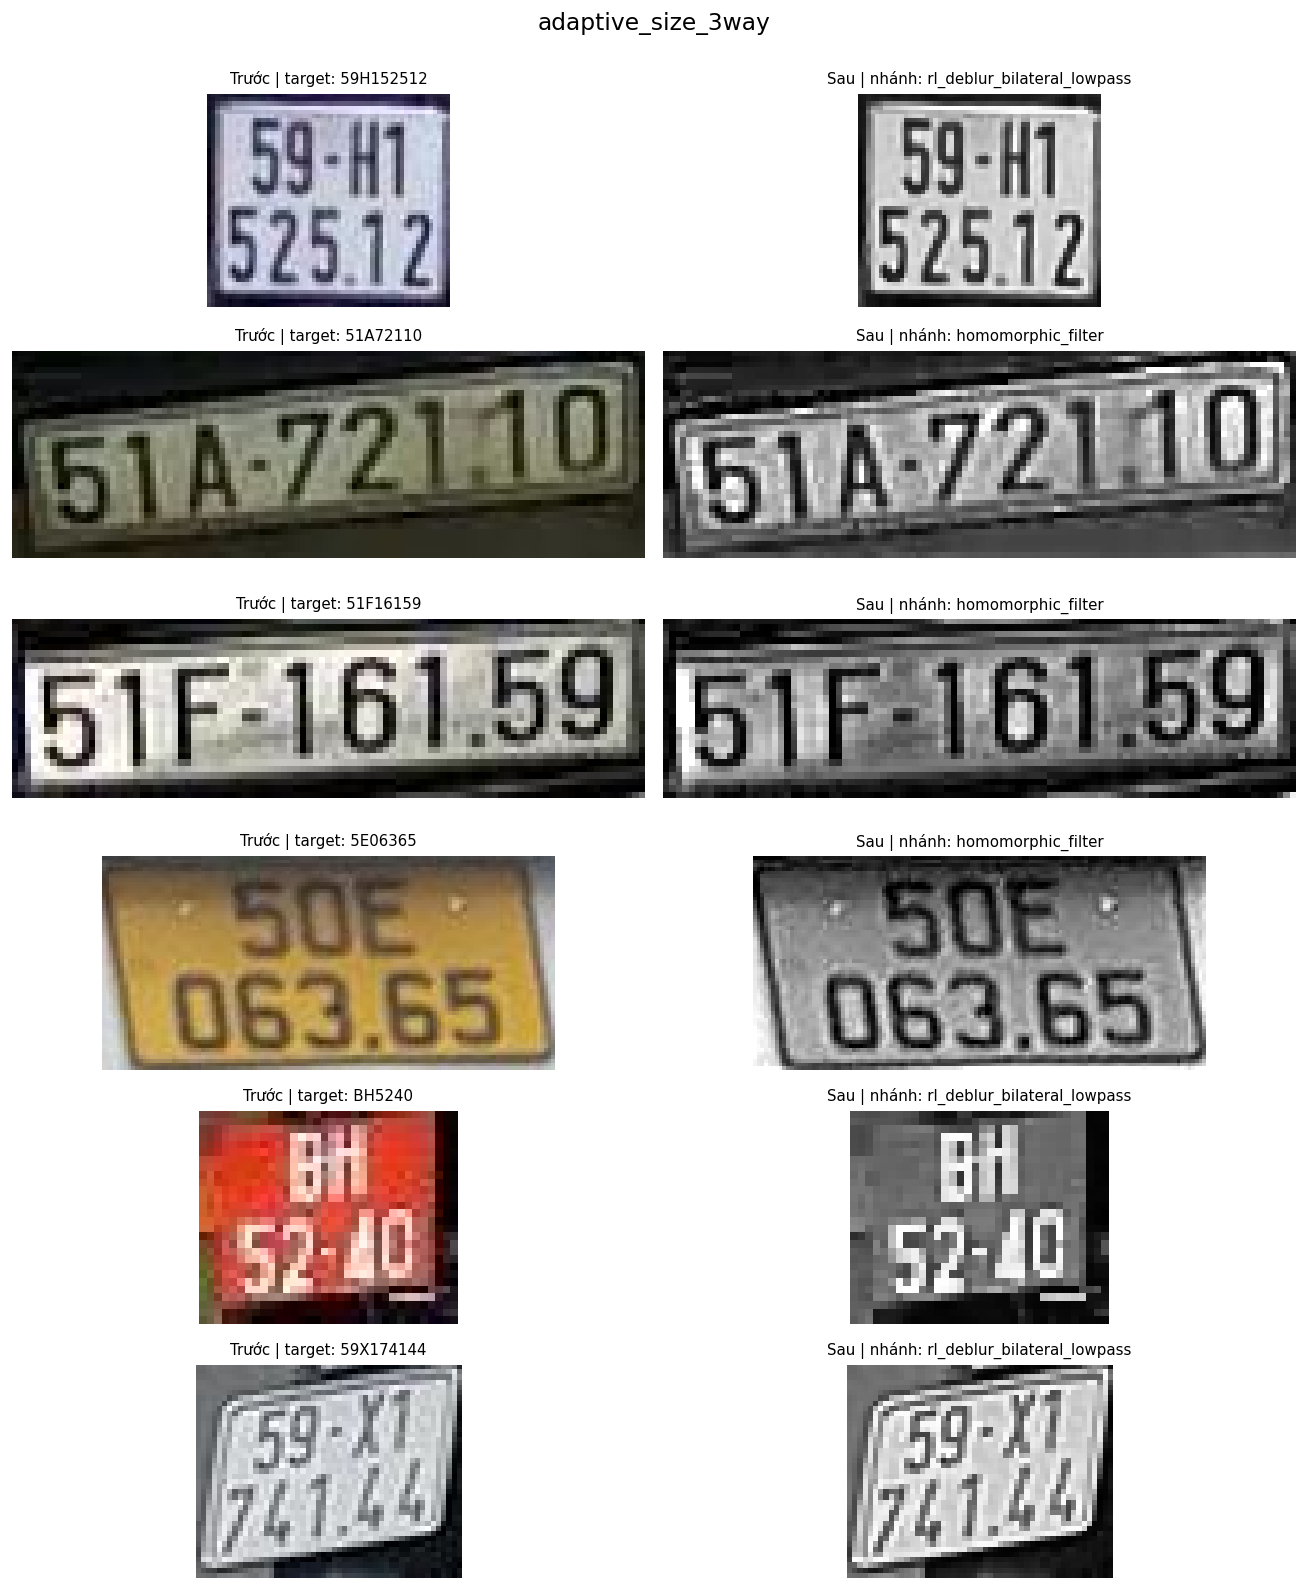


### `rl_deblur_bilateral_lowpass`

- Nhóm: Tổ hợp nhiều bước
- Exact match: 92.2141% (+0.2433 điểm % so với baseline)
- Character accuracy: 98.8982% (+0.0298 điểm % so với baseline)
- Vì sao cải thiện: Khử mờ phục hồi cạnh ký tự, còn bilateral/low-pass giảm ringing và nhiễu cao tần sinh ra sau phục hồi.
- Hạn chế: Mức tăng nhỏ, có 7 ảnh bị làm sai và CI 95% chứa 0.


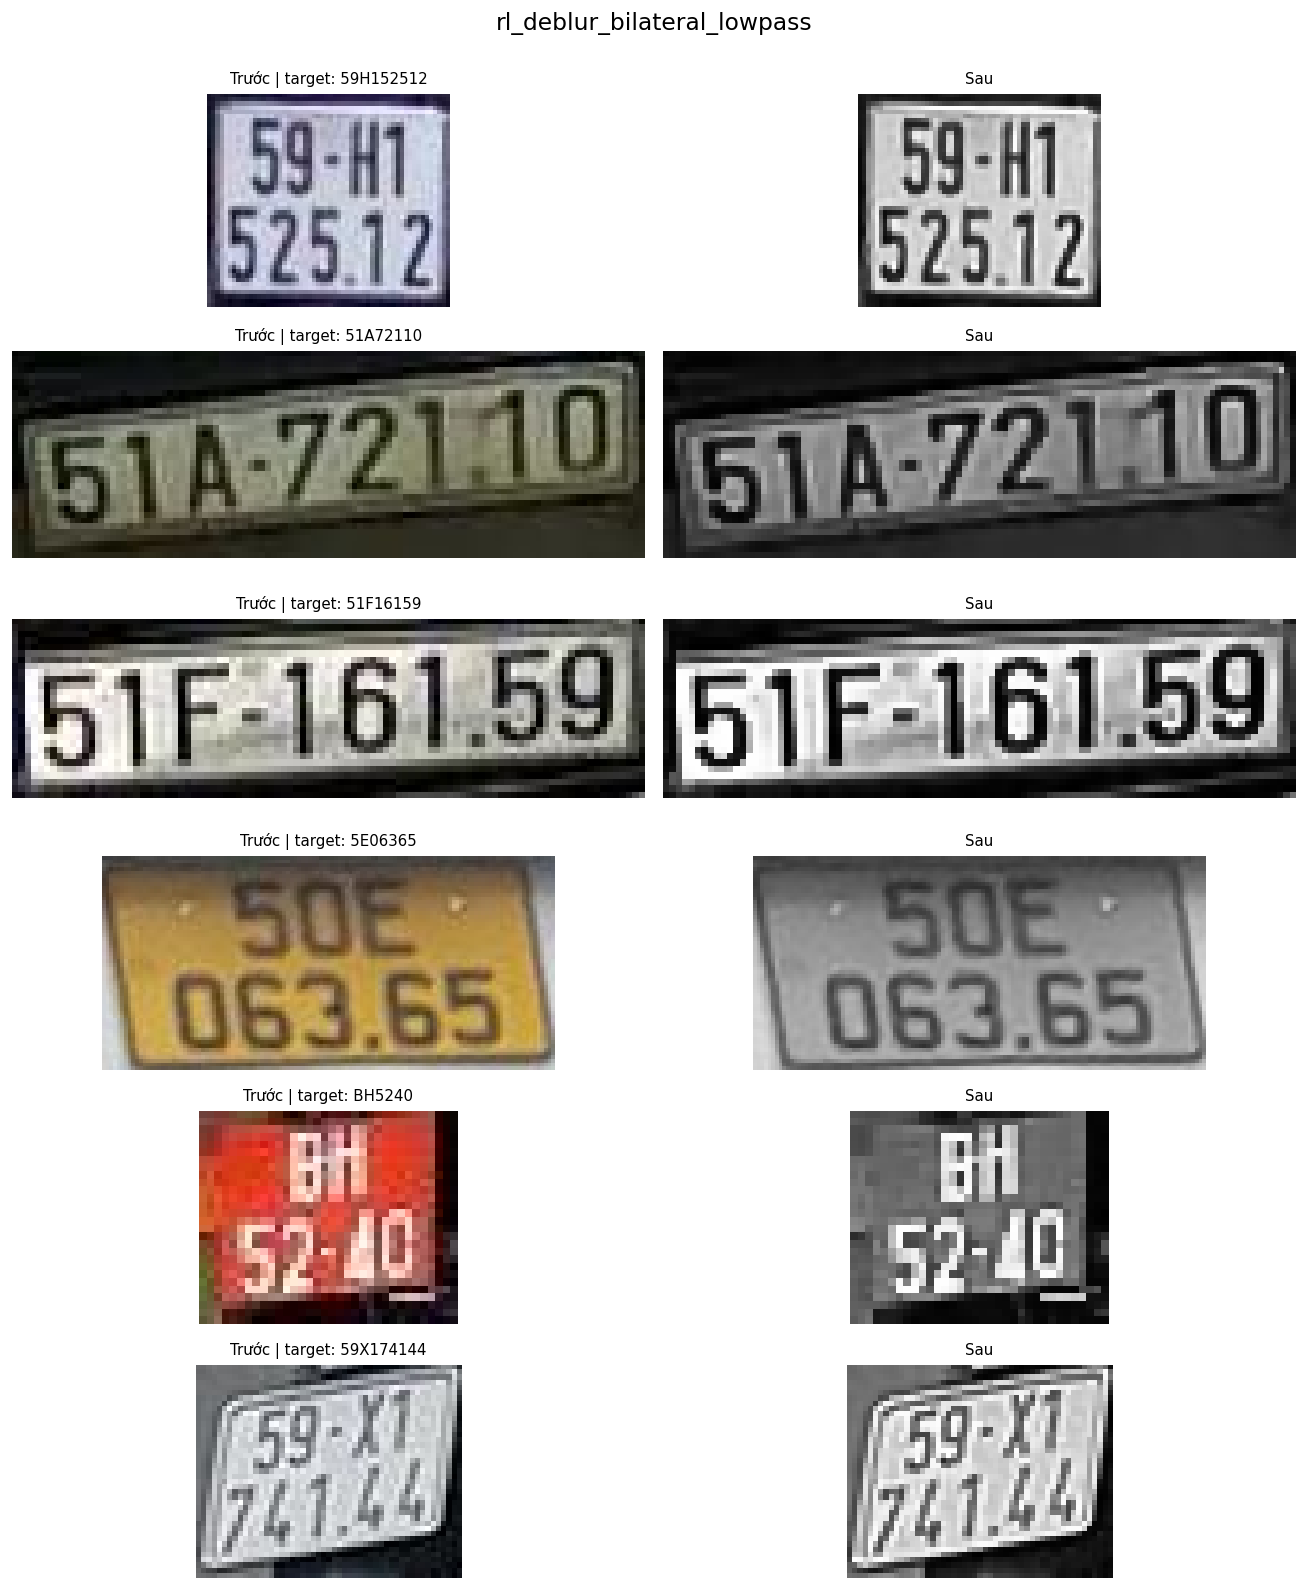


### `percentile_rl_bilateral`

- Nhóm: Tổ hợp nhiều bước
- Exact match: 92.2141% (+0.2433 điểm % so với baseline)
- Character accuracy: 98.6897% (-0.1787 điểm % so với baseline)
- Vì sao cải thiện: Tăng tương phản trước khi khử mờ giúp thuật toán phục hồi nhìn rõ biên hơn; bilateral giảm nhiễu sau đó.
- Hạn chế: Exact match tăng nhưng character accuracy giảm đáng kể so với baseline; CI 95% chứa 0.


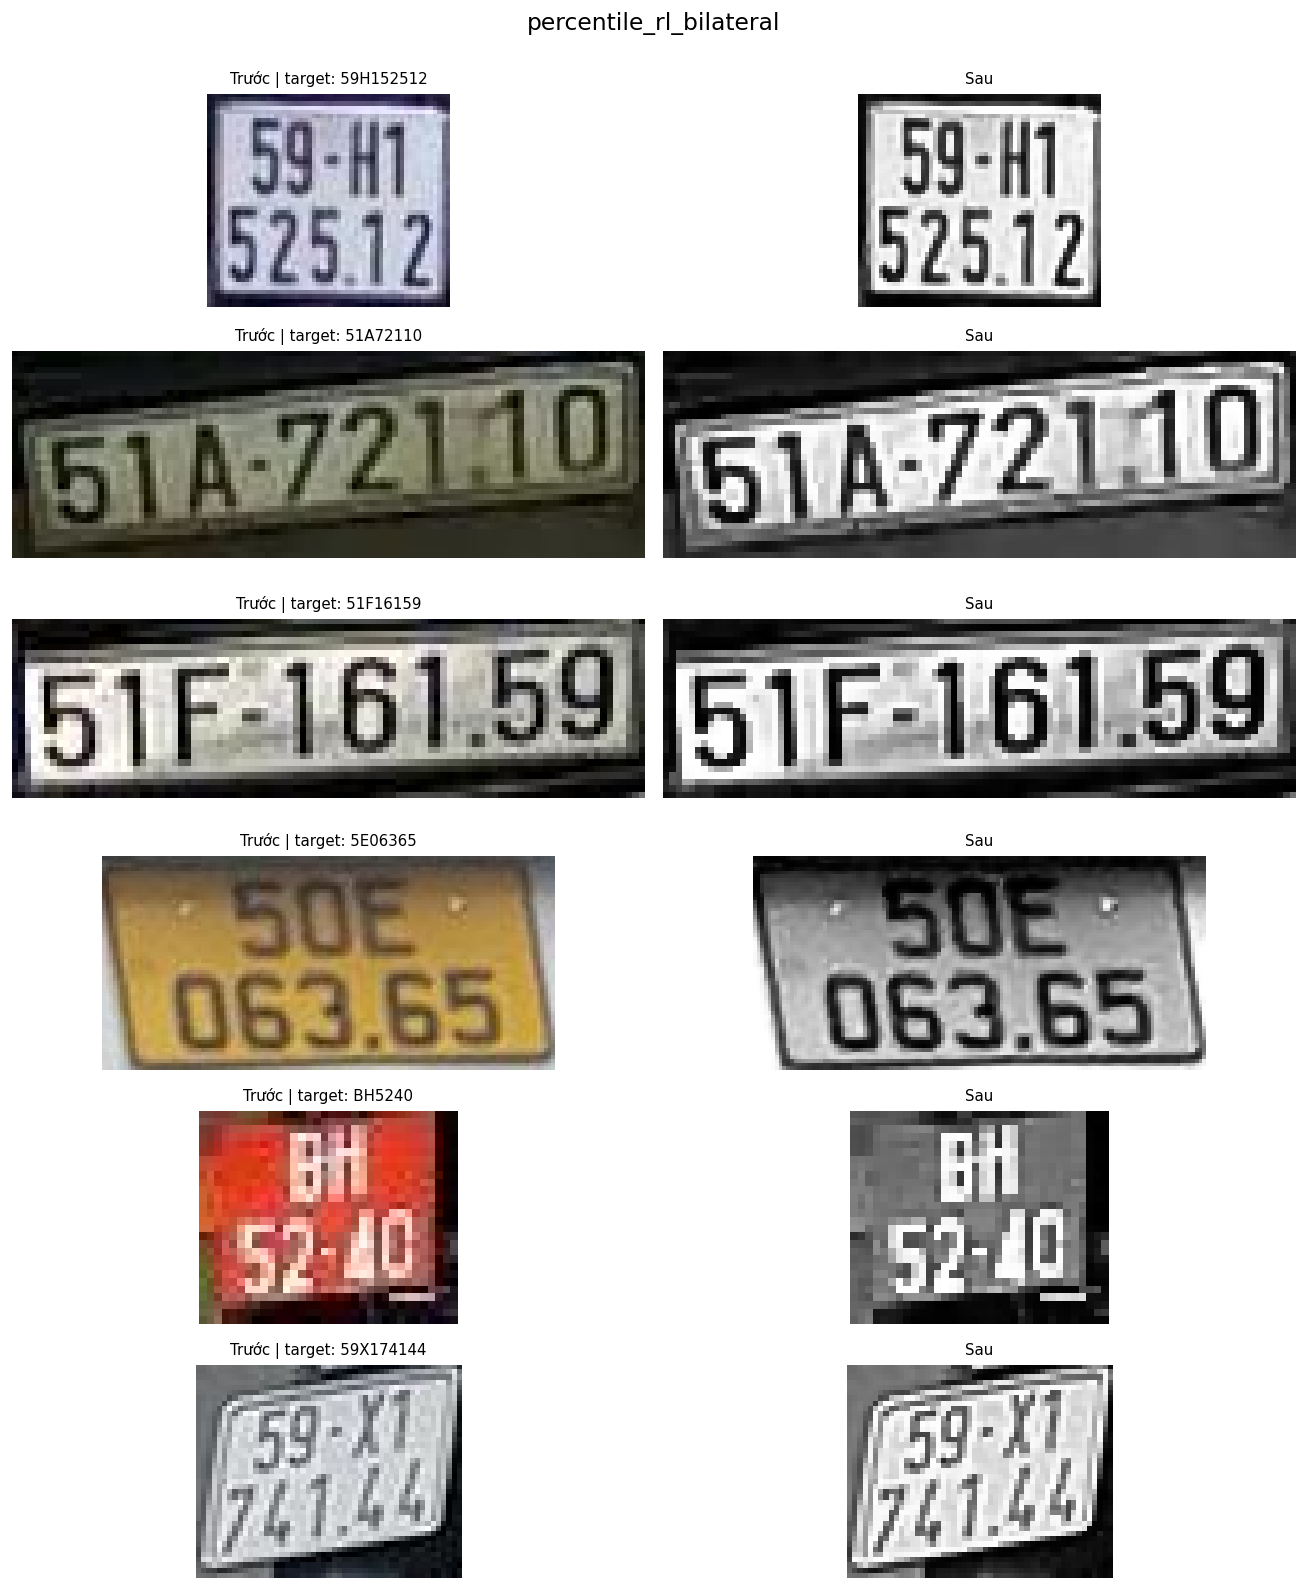

In [20]:
for _, method_row in methods.iterrows():
    explain_method(method_row)
    plot_method(method_row, samples)

## Xem riêng một phương pháp

Dùng cell này khi chỉ muốn kiểm tra một cấu hình cụ thể.

In [21]:
# Ví dụ:
# show_method("adaptive_noise_3way")
# show_method("clahe_rl_deblur_bilateral")
# show_method("rl_deblur_bilateral_lowpass")